# Etherium Price Prediction

## A. Business Understanding


### Background

Pasar aset kripto seperti Ethereum (ETH) merupakan salah satu pasar aset yang memiliki volatilitas harga yang sangat tinggi. Fluktuasi harga yang cepat membuat para trader dan investor menghadapi tantangan besar dalam membuat keputusan investasi yang tepat waktu dan menguntungkan. Oleh karena itu, diperlukan alat bantu berbasis data yang mampu memprediksi pergerakan harga di masa depan secara akurat.Dengan bantuan machine learning atau model statistik, prediksi jangka pendek dapat dilakukan untuk membantu pengambilan keputusan dalam aktivitas trading atau manajemen risiko.



### Problem

Dengan volatilitas harga yang tinggi, apakah ada model prediksi yang dapat memprediksi harga Ethereum dengan akurasi yang tinggi?

### Objective

* Mengembangkan model prediksi harga Ethereum (ETH) berbasis time series forecasting.
* Model ini akan memanfaatkan data historis harga Ethereum setiap 15 menit (interval 15m).

### Goals

* Memprediksi harga Ethereum dengan model prediksi
* Memberikan rekomendasi actionable terhadap fluktuasi harga seperti kapan saatnya beli atau jual Ethereum.

## B. Data Understanding

### Import Library

In [72]:
!pip install arch

In [73]:
import pandas as pd
import numpy as np
import random
import os
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import torch
import torch.nn as nn
from arch import arch_model
import matplotlib.dates as mdates

### Import Data

In [74]:
df = pd.read_csv('/content/ETH_15min_2017-08-17_to_2025-07-27 new.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 277966 entries, 0 to 277965
Data columns (total 6 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   datetime  277966 non-null  object 
 1   open      277966 non-null  float64
 2   high      277966 non-null  float64
 3   low       277966 non-null  float64
 4   close     277966 non-null  float64
 5   volume    277966 non-null  float64
dtypes: float64(5), object(1)
memory usage: 12.7+ MB


* Jumlah baris 277.966
* Interval waktu harga setiap 15 menit
* Rentang waktu dari 17 Agustus 2017 sampai 27 Juli 2025

### Data Dictionary

Data Dictionary:
* datetime -> tanggal dan waktu transaksi
* Open -> harga awal pada rentang 15 menit
* high -> harga tertinggi
* low -> harga terendah
* close -> harga penutupan pada akhir rentang 15 menit
* Volume -> Jumlah transaksi ETH pada rentang itu


In [75]:
df.head()

,datetime,open,high,low,close,volume
0,2017-08-17 04:00:00,301.13,301.13,298.00,298.00,5.80167
1,2017-08-17 04:15:00,298.00,300.80,298.00,299.39,31.44065
2,2017-08-17 04:30:00,299.39,300.79,299.39,299.60,52.93579
3,2017-08-17 04:45:00,299.60,302.57,299.60,301.61,35.49066
4,2017-08-17 05:00:00,301.61,302.57,300.95,302.01,81.69235


In [76]:
df.tail()

,datetime,open,high,low,close,volume
277961,2025-07-27 11:30:00,3824.23,3831.86,3810.96,3814.53,5932.7263
277962,2025-07-27 11:45:00,3814.53,3818.21,3804.77,3815.26,4276.7642
277963,2025-07-27 12:00:00,3815.26,3835.00,3815.17,3834.00,8894.1027
277964,2025-07-27 12:15:00,3834.00,3836.54,3813.27,3814.97,6975.6250
277965,2025-07-27 12:30:00,3814.98,3818.79,3814.98,3815.65,782.1571


## C. Data Preprocessing

### Data Type

In [77]:
# Ubah 'datetime' ke format datetime dan jadikan index
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.set_index('datetime')

### Duplicate

In [78]:
df.duplicated().sum()

np.int64(58)

### Missing Value

In [79]:
df.isnull().sum()

,0
open,0
high,0
low,0
close,0
volume,0


### Outlier

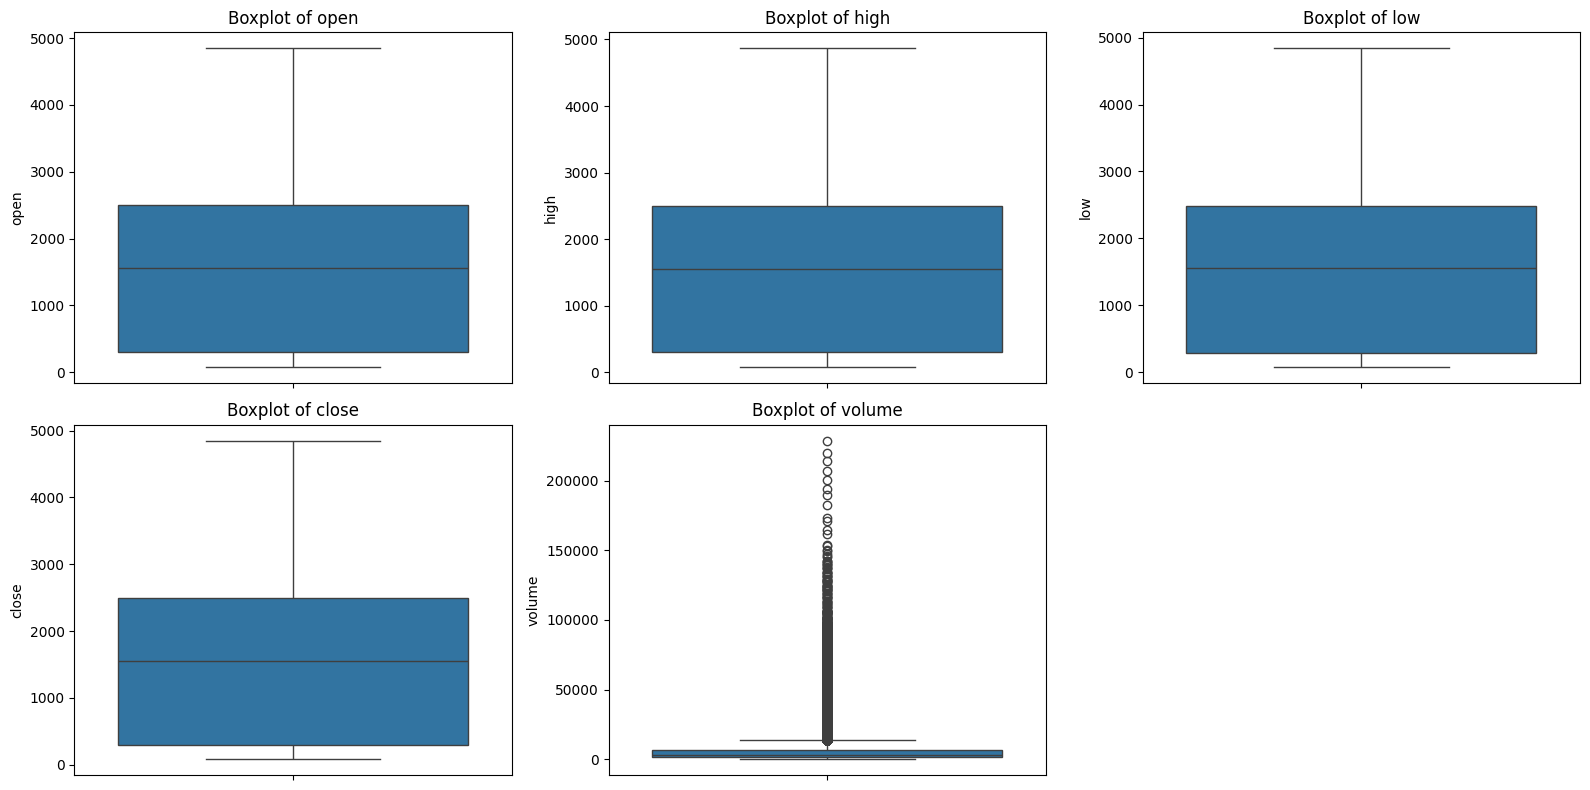

In [80]:
# Kolom-kolom yang ingin dicek
cols = ['open', 'high', 'low', 'close', 'volume']

# Plot boxplot
plt.figure(figsize=(16, 8))
for i, col in enumerate(cols):
    plt.subplot(2, 3, i+1)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

Pada kolom `volume` terdapat outlier, namun tidak akan dilakukan drop pada outlier tersebut karena volatilitas pasar aset crypto memang membuat jumlah volume transaksi bisa sangat tinggi dan sangat rendah. Selain itu melakukan drop pada outlier akan membuat kehilangan banyak data yang penting

## D. EDA

In [81]:
## Deskriptif Statistik
df.describe()

,open,high,low,close,volume
count,277966.000000,277966.000000,277966.000000,277966.000000,277966.000000
mean,1530.448442,1534.690508,1526.028269,1530.458953,5543.548712
std,1222.198149,1225.315089,1218.923968,1222.204854,7664.301443
min,82.160000,82.510000,81.790000,82.170000,0.000000
25%,295.252500,296.360000,294.220000,295.260000,1623.352617
50%,1553.875000,1557.380000,1550.105000,1553.875000,3262.050750
75%,2494.765000,2501.862500,2487.862500,2494.790000,6515.041705
max,4846.940000,4868.000000,4842.300000,4846.840000,228653.146400


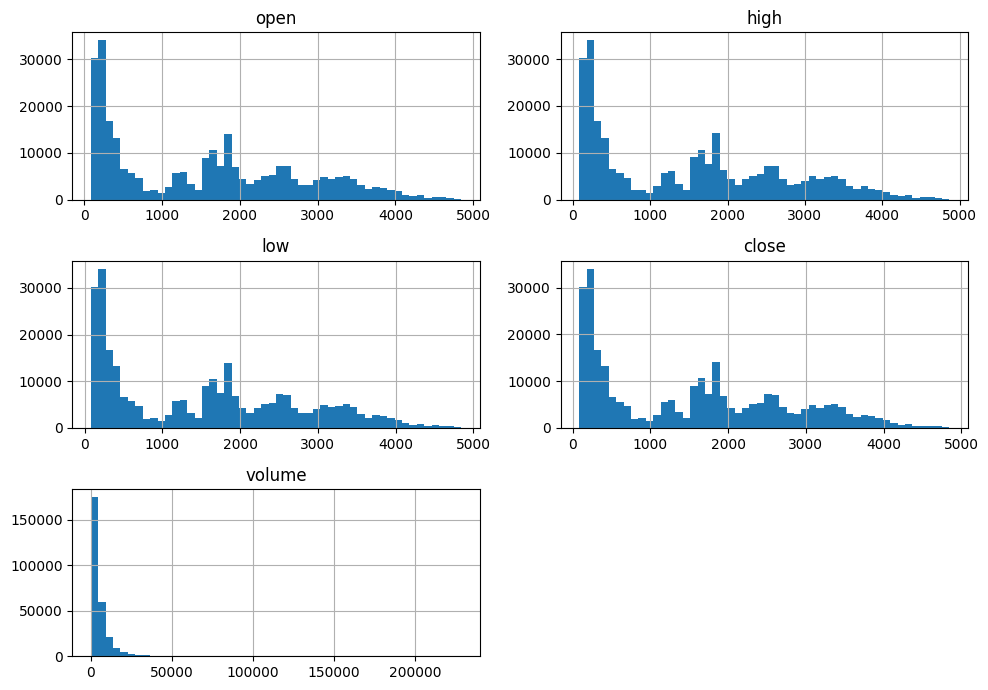

In [82]:
# visualisasi distribusi kolom
df.hist(bins=50, figsize=(10, 7))
plt.tight_layout()
plt.show()

Dari visualisasi dapat diketahui bahwa semua kolom memiliki distribusi data yang skew positif/kanan. Yang artinya semakin rendah harga ETH semakin banyak yang membeli nya.

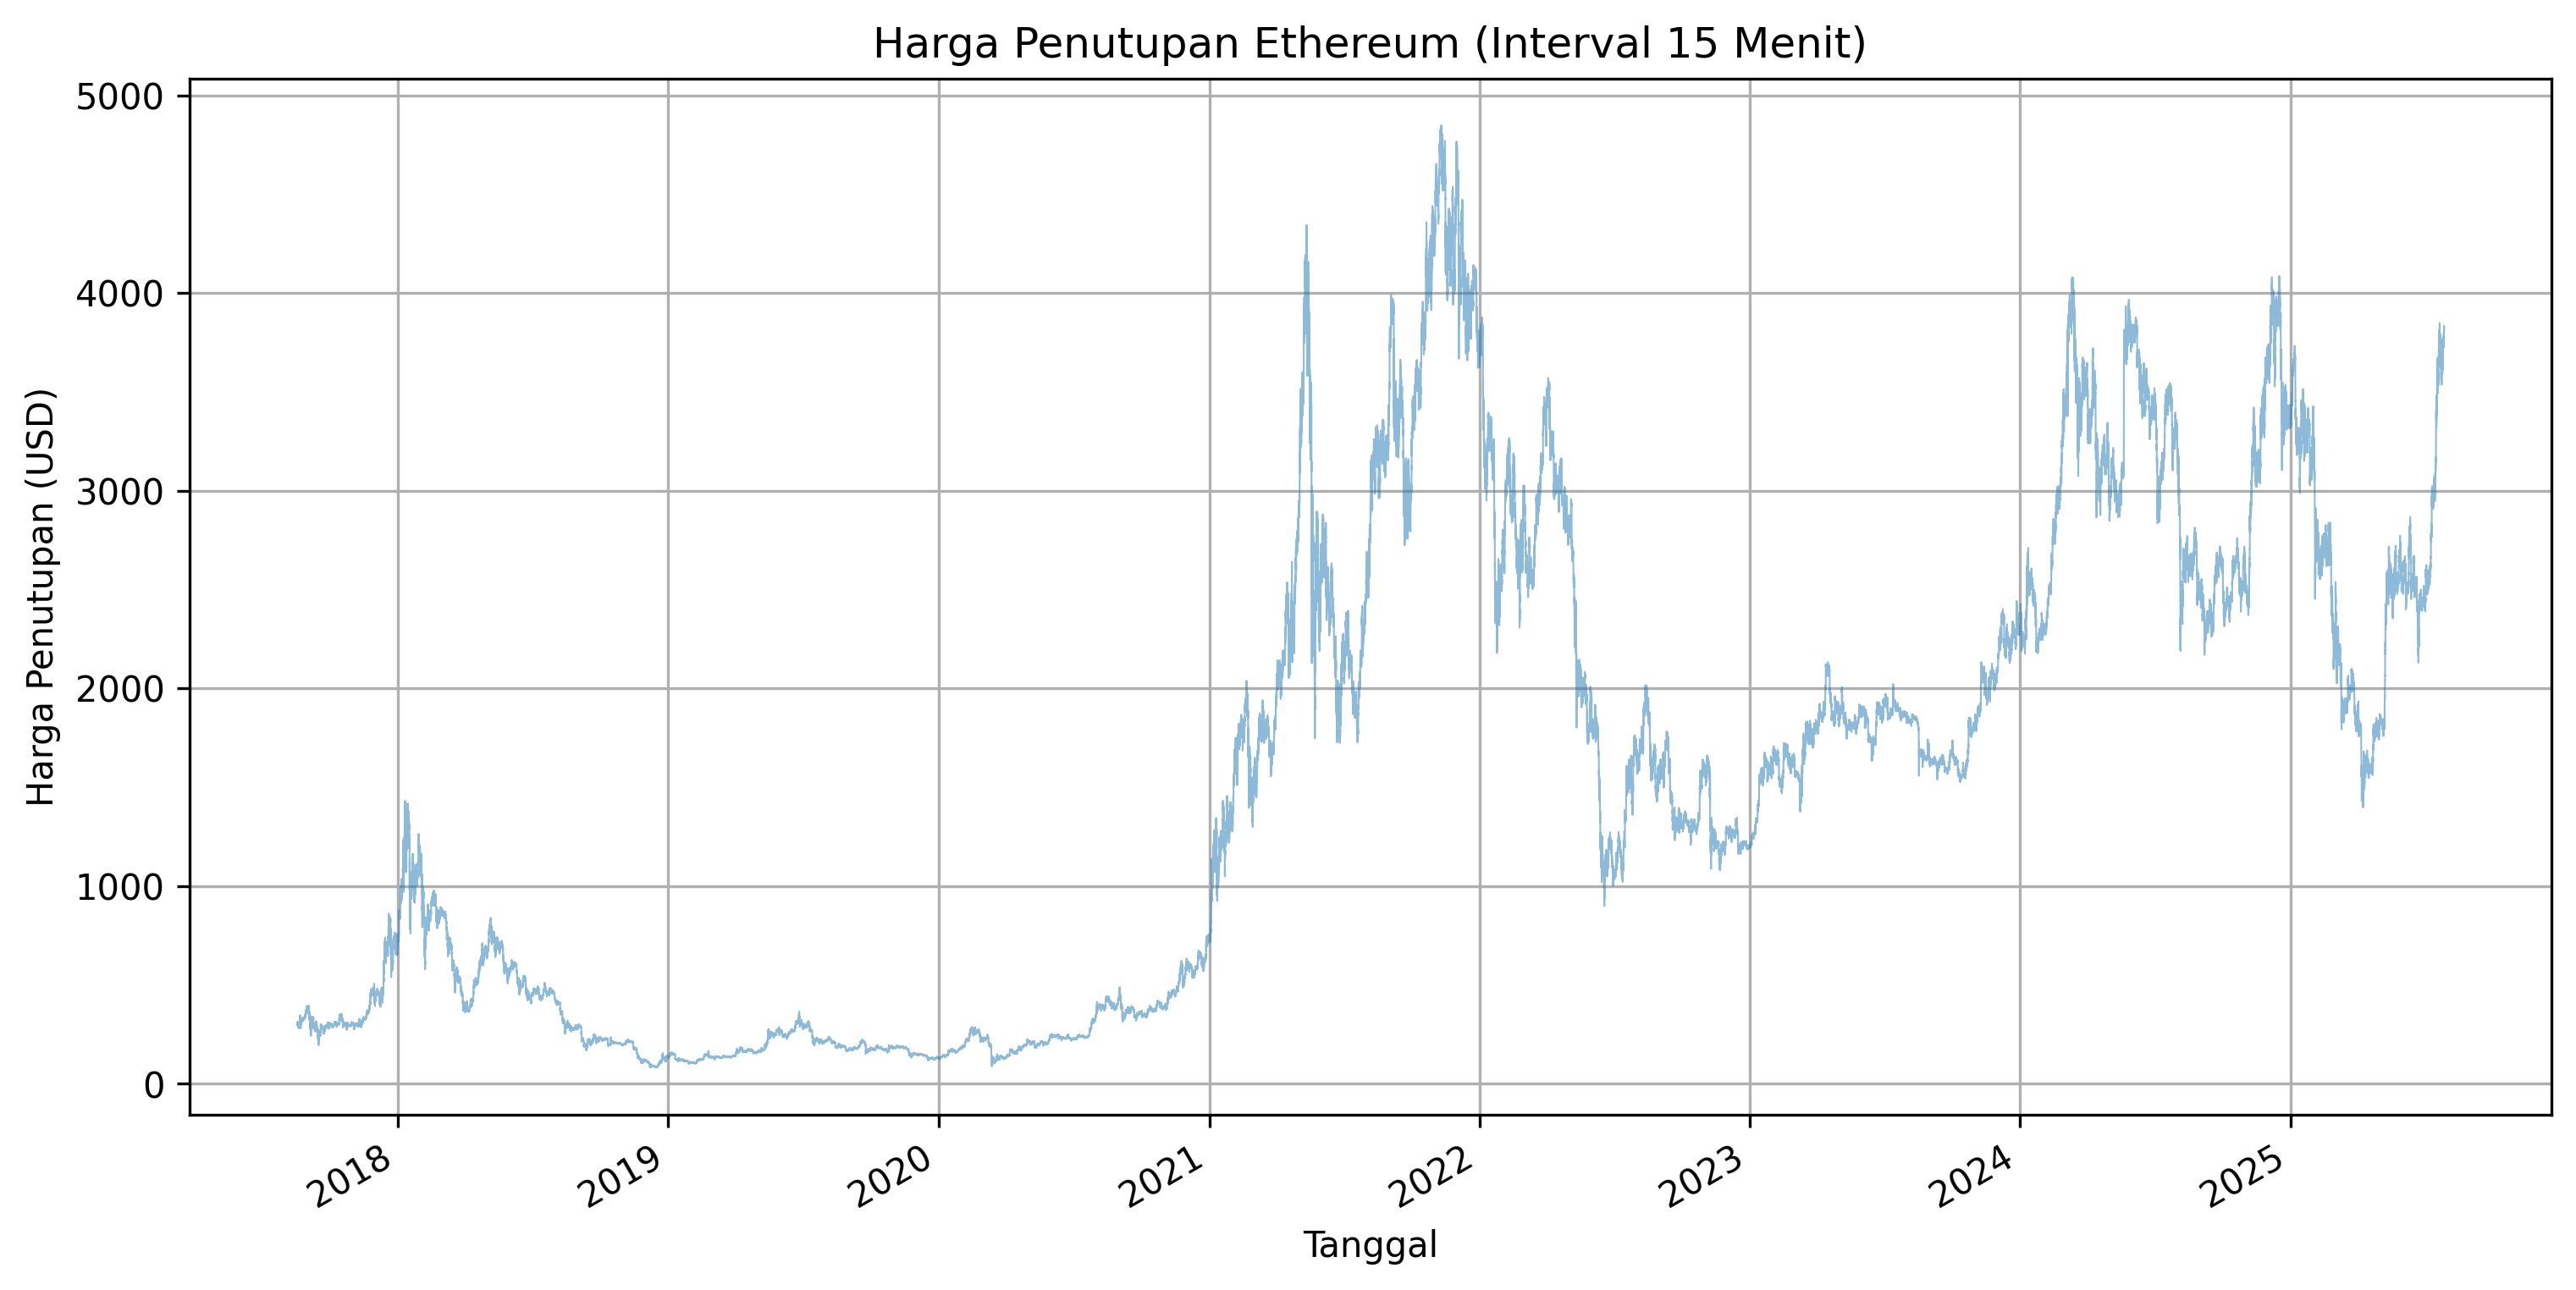

In [83]:
# Visualisasi harga penutupan 15 menit
plt.figure(figsize=(12, 6), dpi=300)
df['close'].plot(alpha=0.5, linewidth=0.5)
plt.title("Harga Penutupan Ethereum (Interval 15 Menit)")
plt.xlabel("Tanggal")
plt.ylabel("Harga Penutupan (USD)")
plt.grid(True)
plt.show()


In [84]:
# Resample ke harian (1D) dengan harga penutupan terakhir tiap hari
df_daily = df['close'].resample('1D').mean().to_frame()
df_daily.columns = ['close']
df_daily.head()

,close
datetime,
2017-08-17,306.873750
2017-08-18,300.502396
2017-08-19,290.978958
2017-08-20,294.323750
2017-08-21,320.375938


<Figure size 3600x1800 with 0 Axes>

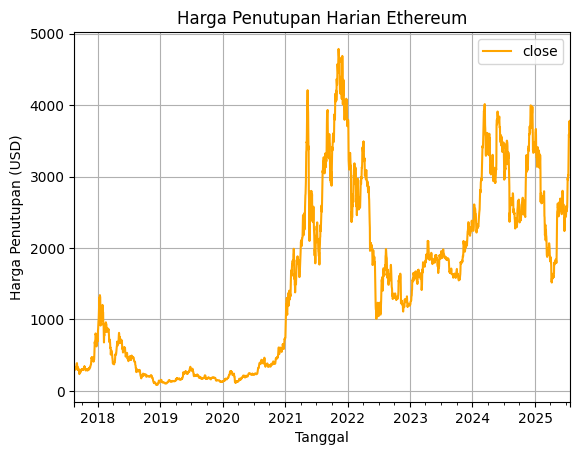

In [85]:
# Visualisasi harga penutupan harian
plt.figure(figsize=(12, 6), dpi=300)
df_daily.plot(color='orange')
plt.title("Harga Penutupan Harian Ethereum")
plt.xlabel("Tanggal")
plt.ylabel("Harga Penutupan (USD)")
plt.grid(True)
plt.show()

In [86]:
## Tanggal & nilai harga tertinggi & terendah
max_high_date = df['high'].idxmax()
max_high_value = df.loc[max_high_date, 'high']

min_low_date = df['low'].idxmin()
min_low_value = df.loc[min_low_date, 'low']

print(f"Harga Tertinggi: {max_high_value:.2f} USDT pada {max_high_date}")
print(f"Harga Terendah: {min_low_value:.2f} USDT pada {min_low_date}")


Harga Tertinggi: 4868.00 USDT pada 2021-11-10 14:15:00
Harga Terendah: 81.79 USDT pada 2018-12-15 15:45:00


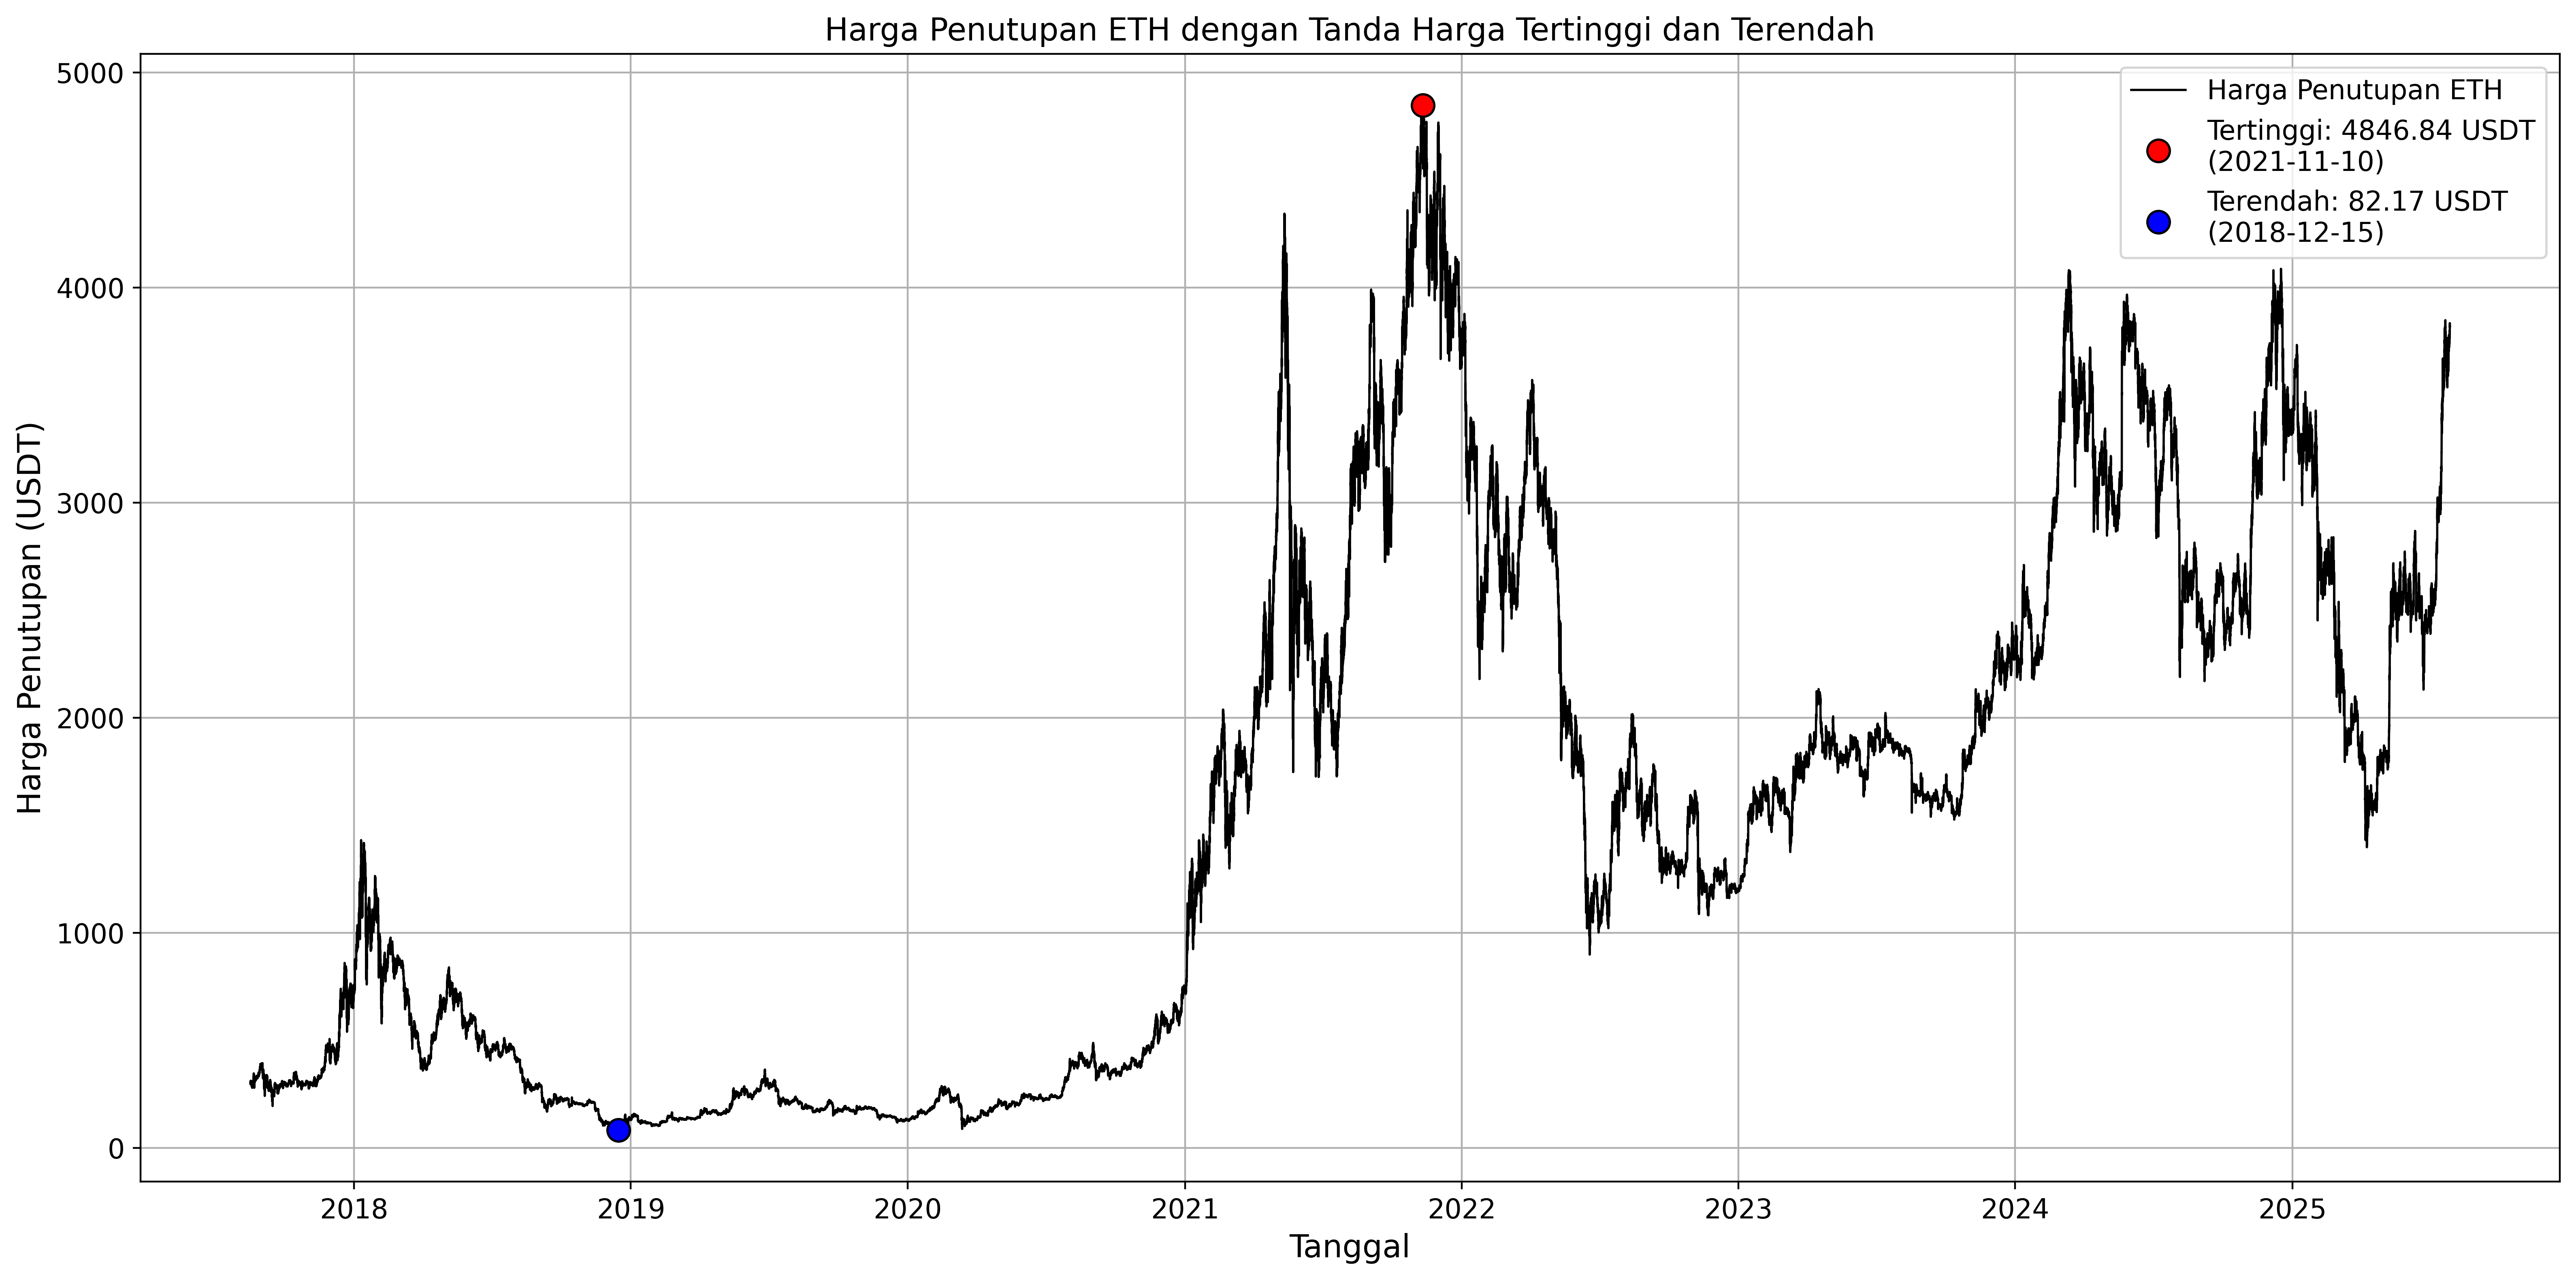

{'Tanggal Harga Tertinggi': '2021-11-10 15:30:00',
 'Harga Tertinggi (USDT)': 4846.84,
 'Tanggal Harga Terendah': '2018-12-15 15:45:00',
 'Harga Terendah (USDT)': 82.17}

In [87]:
# Mengambil harga penutupan untuk tren makro
close = df['close']

# Mencari tanggal dan nilai harga tertinggi dan terendah global
max_price = close.max()
max_price_date = close.idxmax()

min_price = close.min()
min_price_date = close.idxmin()

# Visualisasi
plt.figure(figsize=(16,8), dpi=400)
plt.plot(close.index, close.values, label='Harga Penutupan ETH', color='black', linewidth=1)

# Tanda lingkaran pada harga tertinggi
plt.scatter(max_price_date, max_price, color='red', s=100, edgecolors='black', label=f'Tertinggi: {max_price:.2f} USDT\n({max_price_date.date()})', zorder=5)

# Tanda lingkaran pada harga terendah
plt.scatter(min_price_date, min_price, color='blue', s=100, edgecolors='black', label=f'Terendah: {min_price:.2f} USDT\n({min_price_date.date()})', zorder=5)

plt.title('Harga Penutupan ETH dengan Tanda Harga Tertinggi dan Terendah', fontsize=14)
plt.xlabel('Tanggal',fontsize=14)
plt.ylabel('Harga Penutupan (USDT)', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

# Menampilkan nilai dengan jelas untuk laporan
{
    "Tanggal Harga Tertinggi": str(max_price_date),
    "Harga Tertinggi (USDT)": max_price,
    "Tanggal Harga Terendah": str(min_price_date),
    "Harga Terendah (USDT)": min_price,
}

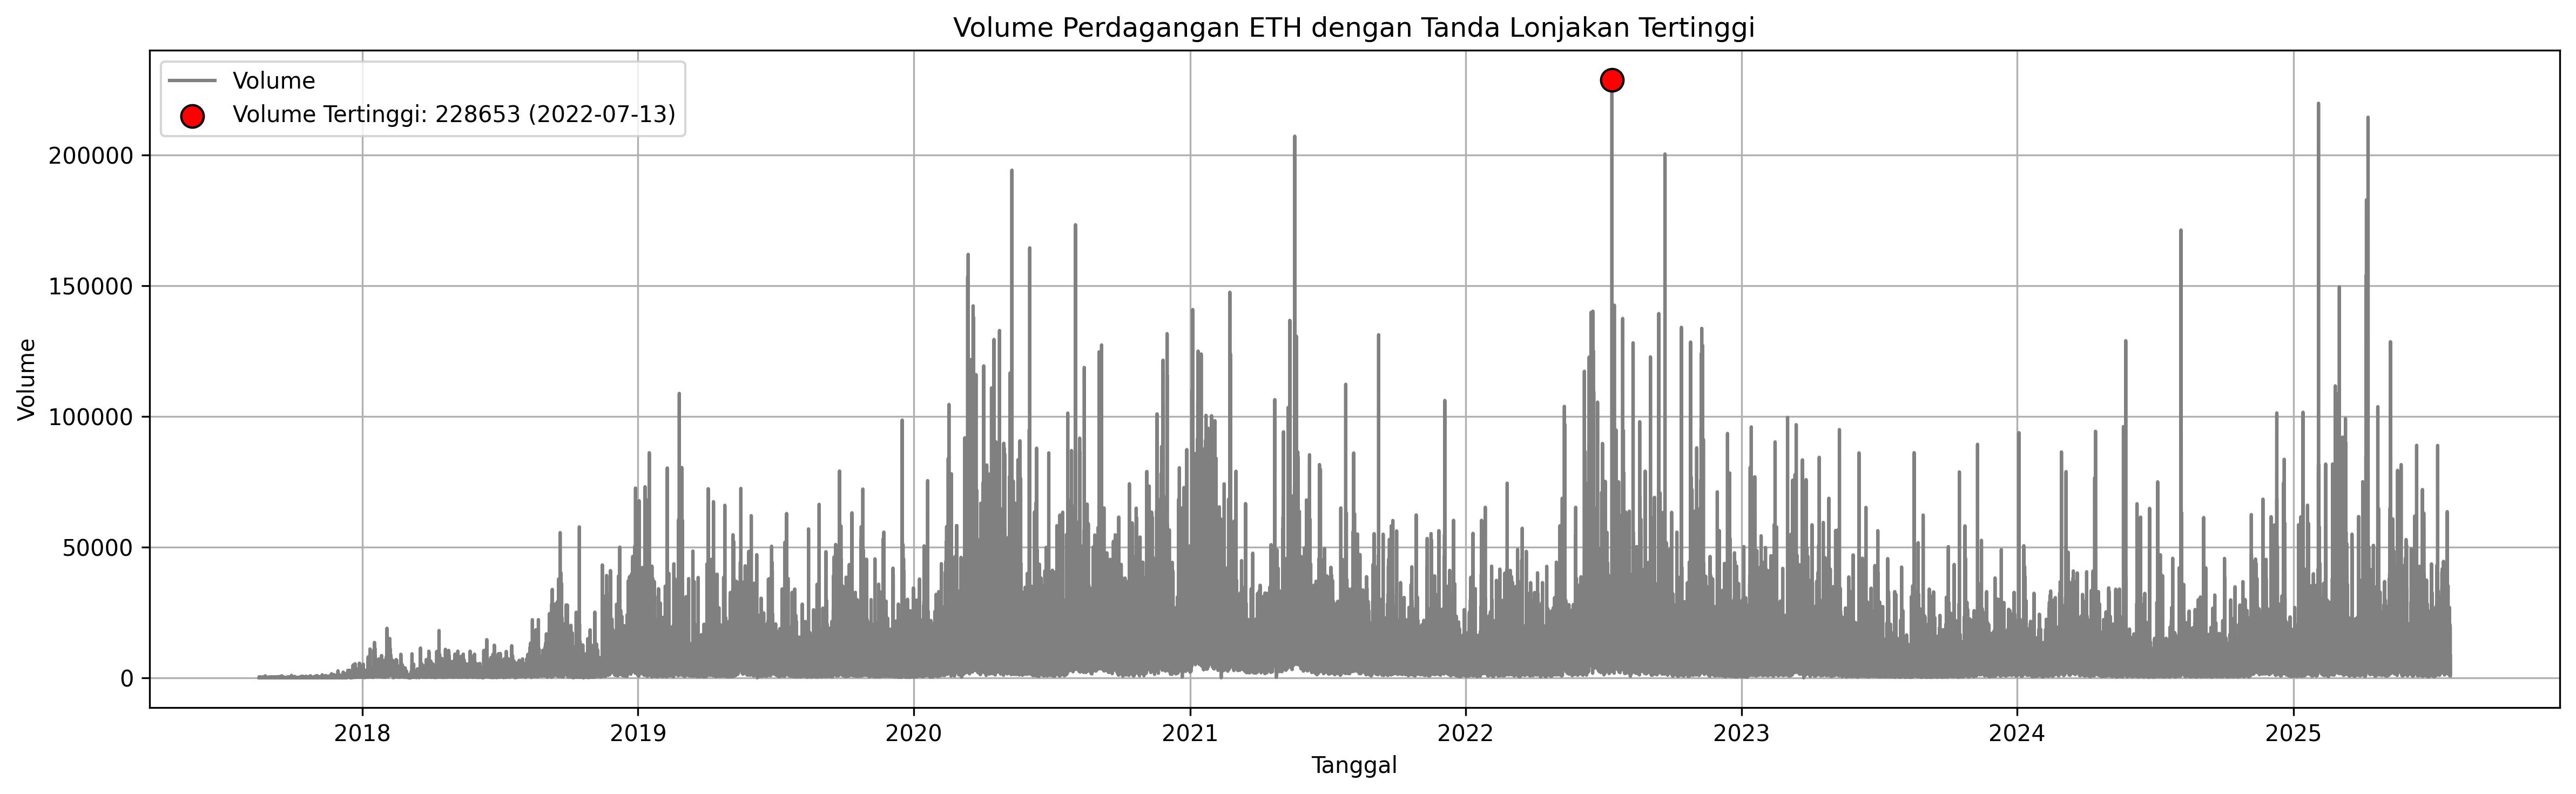

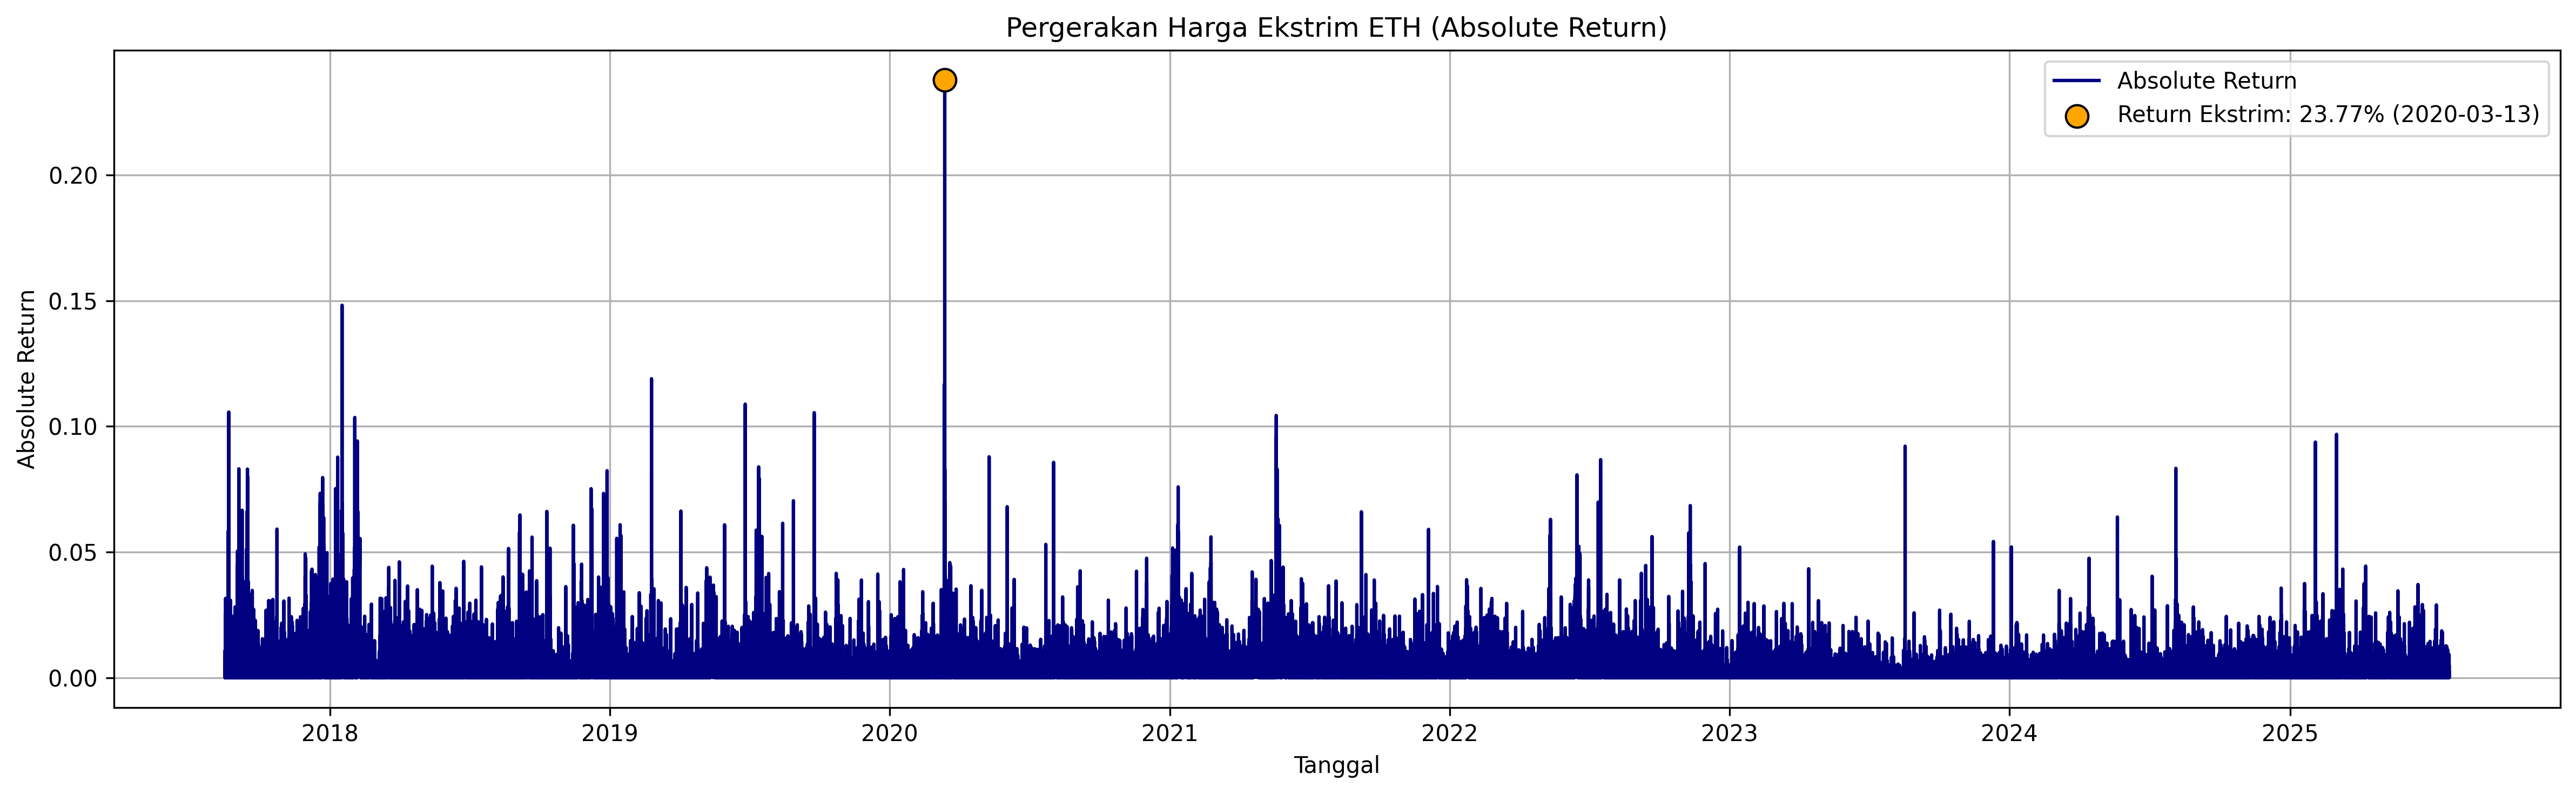

{'Tanggal Volume Tertinggi': '2022-07-13 12:30:00',
 'Volume Tertinggi': np.float64(228653.1464),
 'Tanggal Return Ekstrim Tertinggi': '2020-03-13 02:30:00',
 'Return Ekstrim Tertinggi (%)': np.float64(23.76784411795354)}

In [88]:
# Menghitung return absolut antar waktu sebagai indikasi pergerakan harga ekstrim
df['abs_return'] = df['close'].pct_change().abs()

# Mencari tanggal volume tertinggi
max_volume_date = df['volume'].idxmax()
max_volume_value = df.loc[max_volume_date, 'volume']

# Mencari tanggal return absolut tertinggi (pergerakan harga ekstrim)
max_return_date = df['abs_return'].idxmax()
max_return_value = df.loc[max_return_date, 'abs_return']

# Visualisasi volume selama periode data
plt.figure(figsize=(16,5), dpi=300)
plt.plot(df['volume'], color='gray', label='Volume')
plt.scatter(max_volume_date, max_volume_value, color='red', s=100, edgecolors='black',
            label=f'Volume Tertinggi: {max_volume_value:.0f} ({max_volume_date.date()})', zorder=5)
plt.title('Volume Perdagangan ETH dengan Tanda Lonjakan Tertinggi')
plt.xlabel('Tanggal')
plt.ylabel('Volume')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Visualisasi pergerakan harga ekstrim (return absolut)
plt.figure(figsize=(16,5), dpi=300)
plt.plot(df['abs_return'], color='navy', label='Absolute Return')
plt.scatter(max_return_date, max_return_value, color='orange', s=100, edgecolors='black',
            label=f'Return Ekstrim: {max_return_value*100:.2f}% ({max_return_date.date()})', zorder=5)
plt.title('Pergerakan Harga Ekstrim ETH (Absolute Return)')
plt.xlabel('Tanggal')
plt.ylabel('Absolute Return')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Ringkasan hasil untuk catatan laporan
{
    "Tanggal Volume Tertinggi": str(max_volume_date),
    "Volume Tertinggi": max_volume_value,
    "Tanggal Return Ekstrim Tertinggi": str(max_return_date),
    "Return Ekstrim Tertinggi (%)": max_return_value * 100,
}

In [89]:
df_fe = df_daily.copy()
df_fe['lag_1'] = df_fe['close'].shift(1)
df_fe['lag_2'] = df_fe['close'].shift(2)
df_fe['ma_7'] = df_fe['close'].rolling(window=7).mean()
df_fe['ma_30'] = df_fe['close'].rolling(window=30).mean()
df_fe['day_of_week'] = df_fe.index.dayofweek

In [90]:
df_fe.isna().sum()

,0
close,0
lag_1,1
lag_2,2
ma_7,6
ma_30,29
day_of_week,0


In [91]:
df_fe = df_fe.dropna()

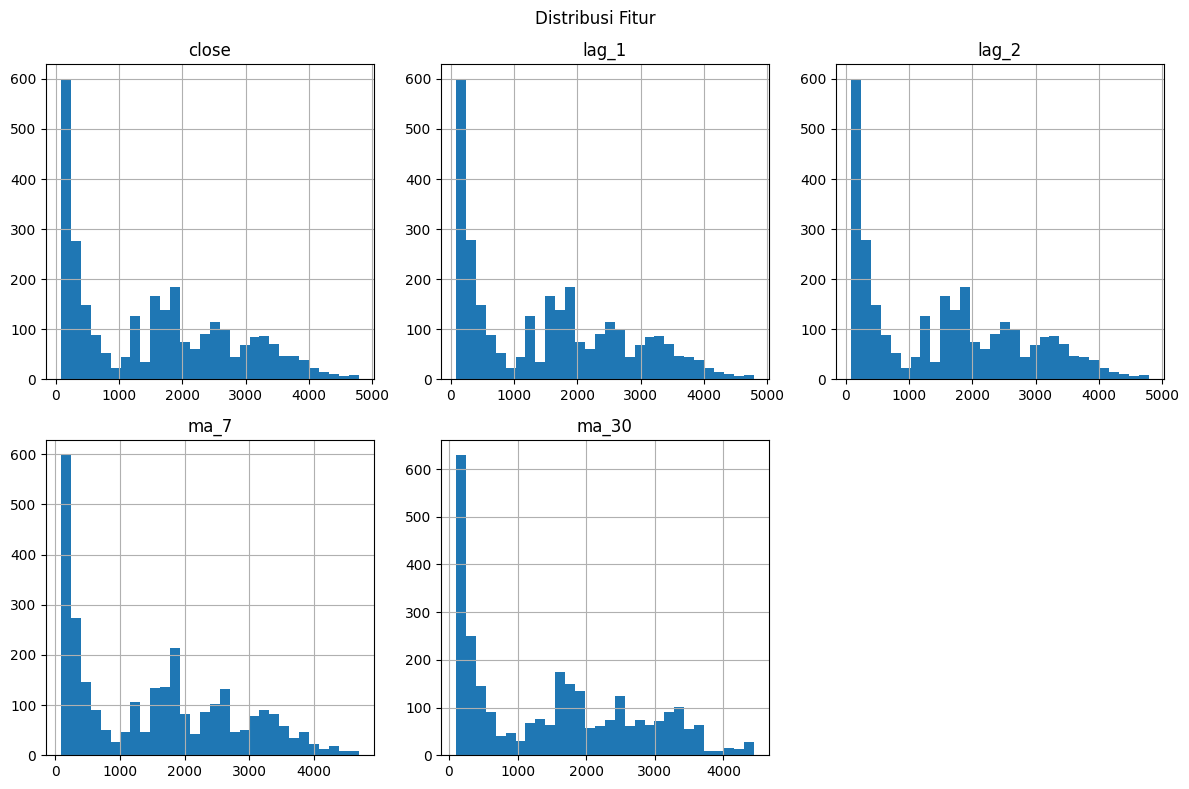

In [92]:
# Plot distribusi fitur penting
features_to_plot = ['close', 'lag_1', 'lag_2', 'ma_7', 'ma_30']
df_fe[features_to_plot].hist(bins=30, figsize=(12, 8), layout=(2, 3))
plt.suptitle("Distribusi Fitur")
plt.tight_layout()
plt.show()


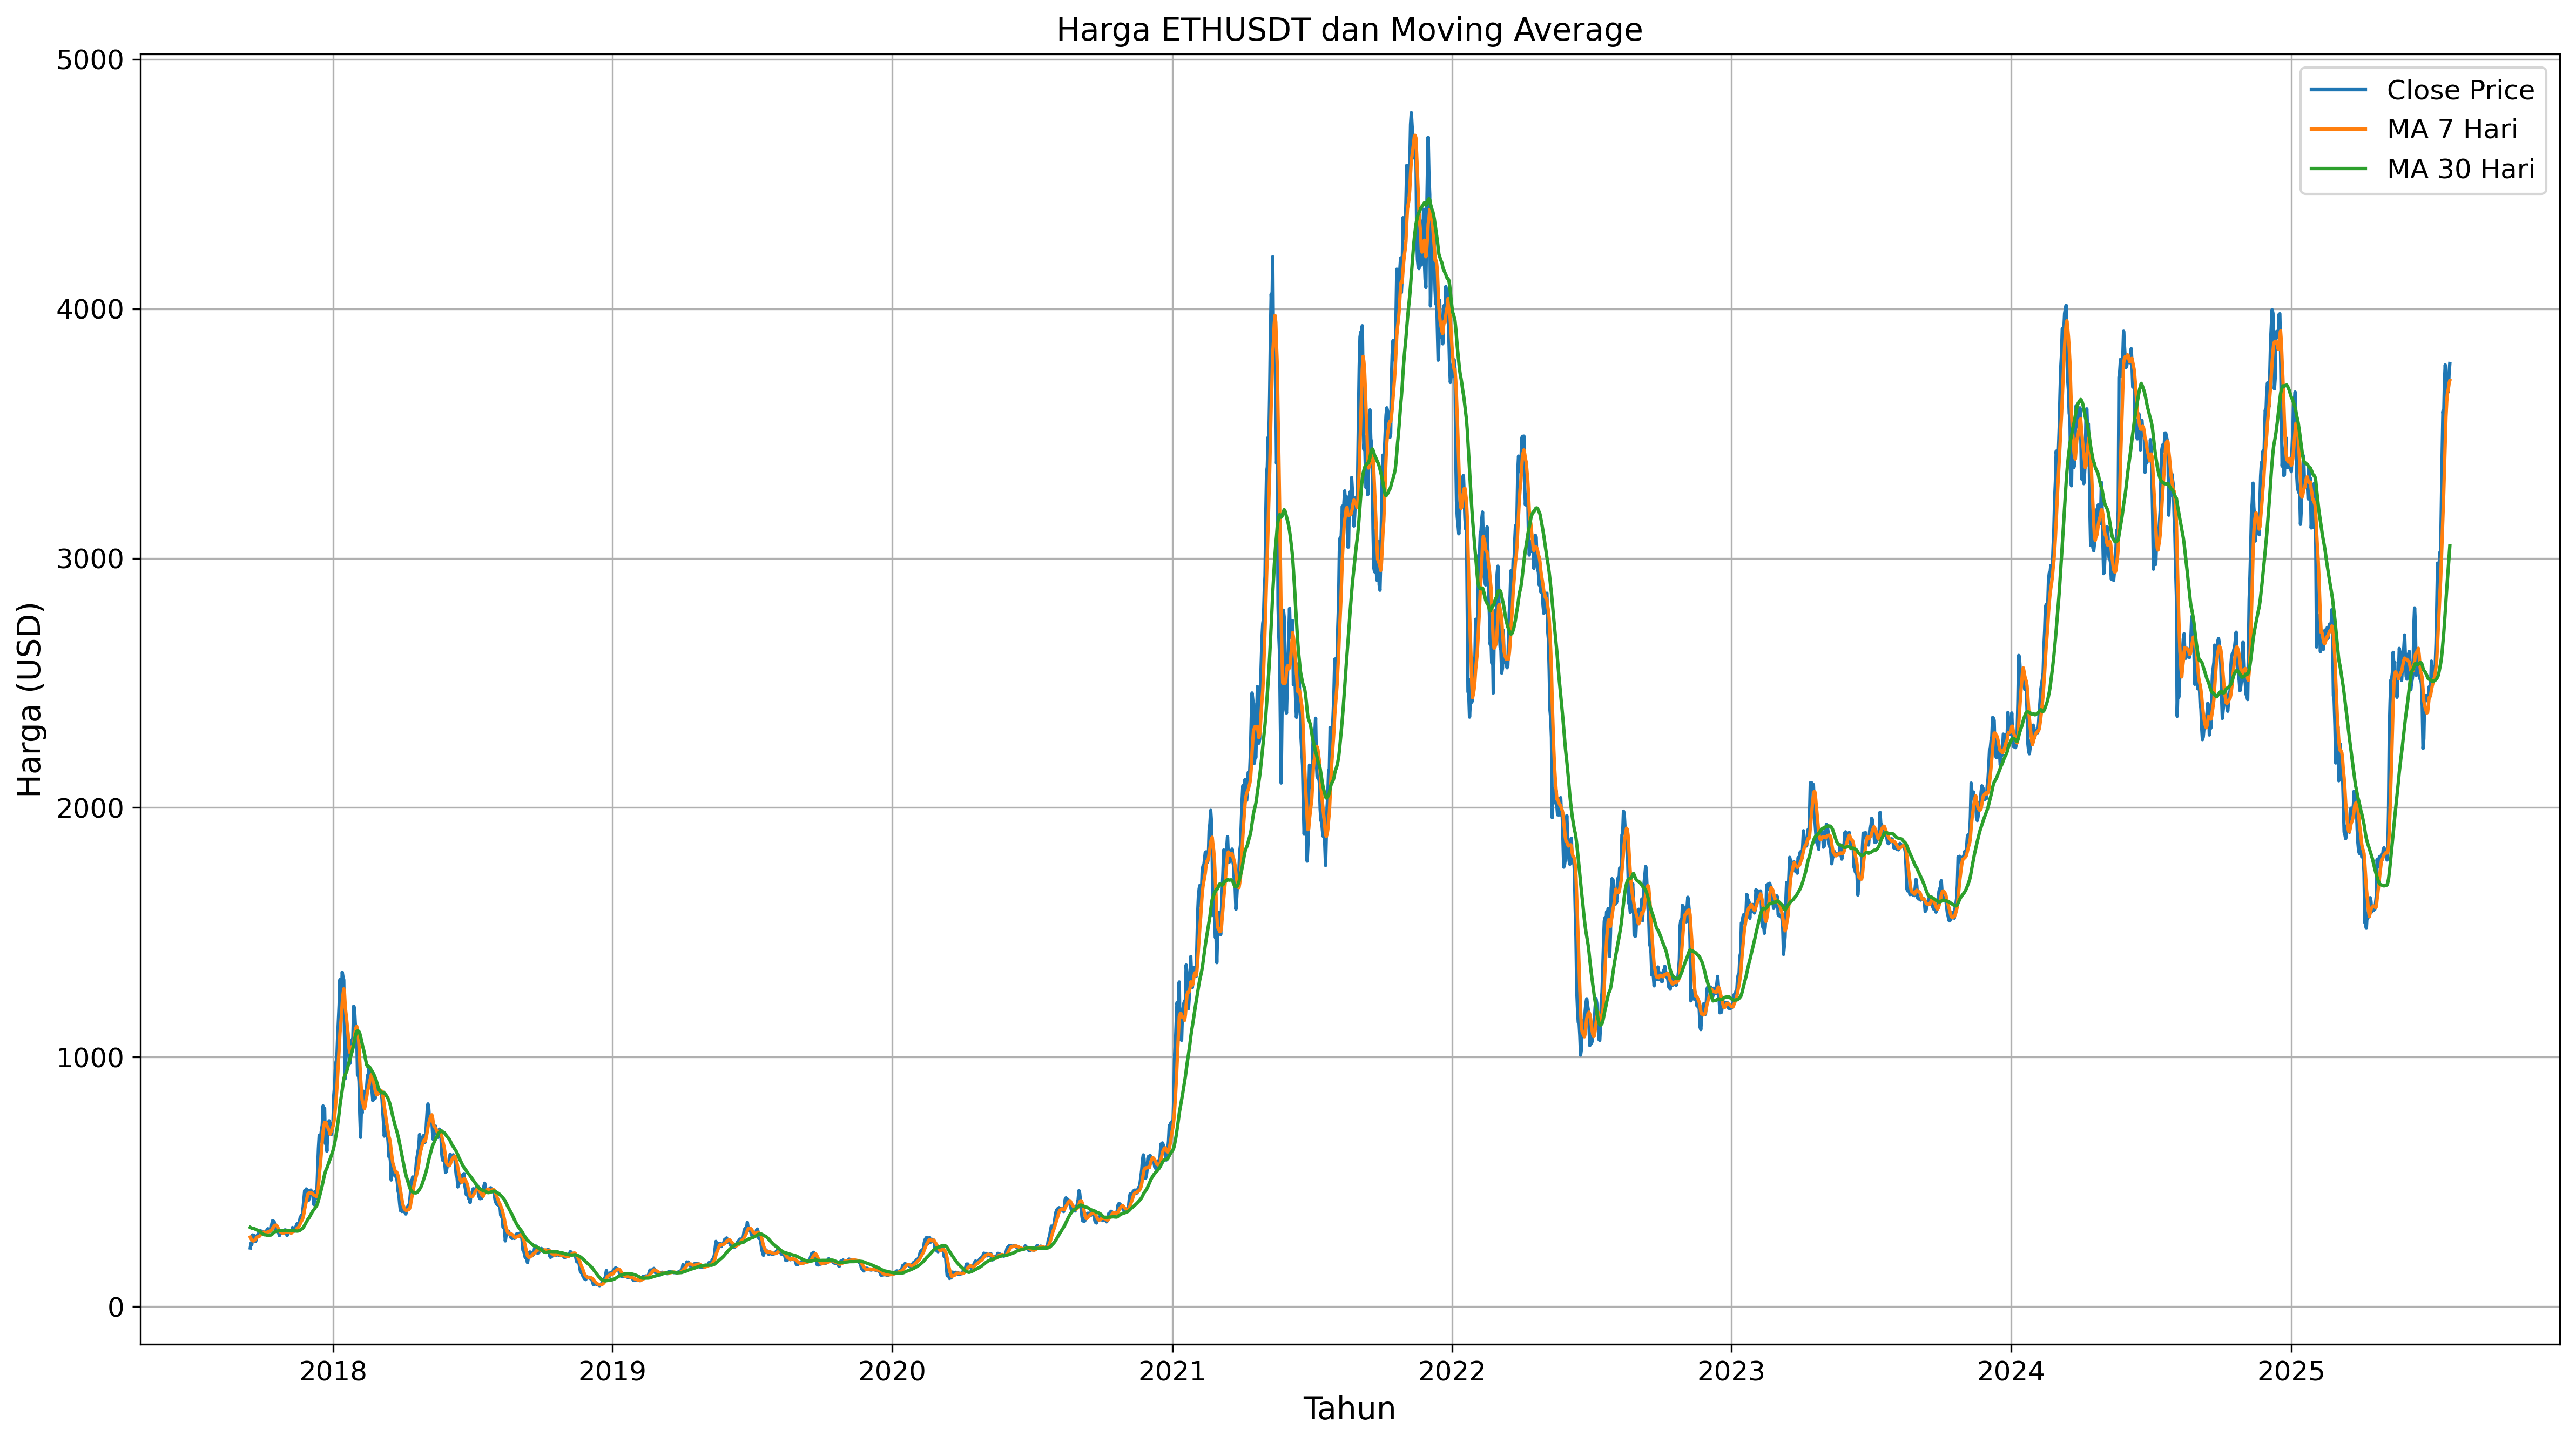

In [93]:
# Plot harga dan moving average
plt.figure(figsize=(16, 9), dpi=300)
plt.plot(df_fe.index, df_fe['close'], label='Close Price')
plt.plot(df_fe.index, df_fe['ma_7'], label='MA 7 Hari')
plt.plot(df_fe.index, df_fe['ma_30'], label='MA 30 Hari')
plt.title("Harga ETHUSDT dan Moving Average", fontsize=14)
plt.legend(fontsize=12)
plt.xlabel("Tahun", fontsize=14)
plt.ylabel("Harga (USD)", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

## E. Modeling

### Split Data

In [94]:
# Persiapan data: menggunakan harga penutupan (close)
data = df_fe['close'].dropna()

# Split 80% train, 20% test
split_idx = int(len(data) * 0.8)
train = data.iloc[:split_idx]
test = data.iloc[split_idx:]

### Prophet

In [95]:
# =============== Prophet Model ===============
prophet_df = data.reset_index()[['datetime', 'close']].rename(columns={'datetime':'ds', 'close':'y'})
prophet_train = prophet_df.iloc[:split_idx]
prophet_test = prophet_df.iloc[split_idx:]

In [96]:
model_prophet = Prophet(daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=False)
model_prophet.fit(prophet_train)

future = model_prophet.make_future_dataframe(periods=len(prophet_test), freq='15min')
forecast = model_prophet.predict(future)

prophet_pred = forecast.iloc[-len(test):]['yhat'].values


DEBUG:cmdstanpy:input tempfile: /tmp/tmpjdhkjv2a/z9ixr94b.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpjdhkjv2a/1z3k89i6.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=57924', 'data', 'file=/tmp/tmpjdhkjv2a/z9ixr94b.json', 'init=/tmp/tmpjdhkjv2a/1z3k89i6.json', 'output', 'file=/tmp/tmpjdhkjv2a/prophet_modelkrc2o7vo/prophet_model-20250801091800.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
09:18:00 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
09:18:01 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [97]:
# Evaluasi Prophet
mape_prophet = np.mean(np.abs((test.values - prophet_pred) / test.values)) * 100
mae_prophet = mean_absolute_error(test.values, prophet_pred)
rmse_prophet = np.sqrt(mean_squared_error(test.values, prophet_pred))

print(f"MAPE Prophet: {mape_prophet:.2f}%")
print(f"MAE Prophet: {mae_prophet:.2f}")
print(f"RMSE Prophet: {rmse_prophet:.2f}")

MAPE Prophet: 29.20%
MAE Prophet: 903.17
RMSE Prophet: 1047.72


### Prophet Hypertuning

In [98]:
# Prophet Hypertuning
best_mape = float('inf')
best_params = {}
for cps in [0.05, 0.1, 0.2]:  # changepoint prior scale
    for sps in [5, 10, 15]:    # seasonality prior scale
        model_prophet_ht = Prophet(daily_seasonality=True, weekly_seasonality=True,
                                   yearly_seasonality=False,
                                   changepoint_prior_scale=cps,
                                   seasonality_prior_scale=sps)
        model_prophet_ht.fit(prophet_train)
        future_ht = model_prophet_ht.make_future_dataframe(periods=len(prophet_test), freq='15min')
        forecast_ht = model_prophet_ht.predict(future_ht)
        prophet_pred_ht = forecast_ht.iloc[-len(test):]['yhat'].values
        mape = np.mean(np.abs((test.values - prophet_pred_ht) / test.values)) * 100
        if mape < best_mape:
            best_mape = mape
            best_params = {'cps': cps, 'sps': sps, 'mape': mape, 'forecast': prophet_pred_ht}



DEBUG:cmdstanpy:input tempfile: /tmp/tmpjdhkjv2a/wppb62up.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpjdhkjv2a/2pcoqxvb.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=18119', 'data', 'file=/tmp/tmpjdhkjv2a/wppb62up.json', 'init=/tmp/tmpjdhkjv2a/2pcoqxvb.json', 'output', 'file=/tmp/tmpjdhkjv2a/prophet_model7ibfko4i/prophet_model-20250801091801.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
09:18:01 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
09:18:02 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
DEBUG:cmdstanpy:input tempfile: /tmp/tmpjdhkjv2a/2y90jjcv.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpjdhkjv2a/9s8t0xop.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/

In [99]:
prophet_pred_ht = best_params['forecast']
mape_prophet_ht = best_params['mape']
mae_prophet_ht = mean_absolute_error(test.values, prophet_pred_ht)
rmse_prophet_ht = np.sqrt(mean_squared_error(test.values, prophet_pred_ht))

print(f"MAPE Prophet Hypertuning: {mape_prophet_ht:.2f}%")
print(f"MAE Prophet Hypertuning: {mae_prophet_ht:.2f}")
print(f"RMSE Prophet Hypertuning: {rmse_prophet_ht:.2f}")

MAPE Prophet Hypertuning: 27.64%
MAE Prophet Hypertuning: 855.22
RMSE Prophet Hypertuning: 1000.16


### LSTM

In [100]:
# Set semua seed agar hasil konsisten
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)  # Kalau pakai GPU
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(42)

In [101]:
# Normalisasi
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data.values.reshape(-1,1))

train_scaled = scaled_data[:split_idx]
test_scaled = scaled_data[split_idx:]

In [102]:
# Dataset LSTM
def create_dataset(dataset, look_back=10):
    X, Y = [], []
    for i in range(len(dataset)-look_back):
        X.append(dataset[i:i+look_back, 0])
        Y.append(dataset[i+look_back, 0])
    return np.array(X), np.array(Y)

In [103]:
look_back = 10
X_train, y_train = create_dataset(train_scaled, look_back)
X_test, y_test = create_dataset(np.concatenate([train_scaled[-look_back:], test_scaled]), look_back)

X_train = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_test = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1)

In [104]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=look_back, hidden_size=32):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        h0 = torch.zeros(1, x.size(0), self.hidden_size)
        c0 = torch.zeros(1, x.size(0), self.hidden_size)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

In [105]:
# Training LSTM
model_lstm = LSTMModel()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_lstm.parameters(), lr=0.01)

for epoch in range(20):
    model_lstm.train()
    output = model_lstm(X_train)
    loss = criterion(output, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

In [106]:
# Prediction LSTM
model_lstm.eval()
with torch.no_grad():
    lstm_pred_scaled = model_lstm(X_test).numpy()
lstm_pred = scaler.inverse_transform(lstm_pred_scaled).flatten()

In [107]:
# Align ukuran prediksi LSTM dengan test
lstm_pred = lstm_pred[:len(test)]

In [108]:
# Evaluasi LSTM
mape_lstm = np.mean(np.abs((test.values - lstm_pred) / test.values)) * 100
mae_lstm = mean_absolute_error(test.values, lstm_pred)
rmse_lstm = np.sqrt(mean_squared_error(test.values, lstm_pred))

print(f"MAPE LSTM: {mape_lstm:.2f}%")
print(f"MAE LSTM: {mae_lstm:.2f}")
print(f"RMSE LSTM: {rmse_lstm:.2f}")

MAPE LSTM: 23.09%
MAE LSTM: 676.78
RMSE LSTM: 724.03


### LSTM Hypertuning

In [109]:
# LSTM Hypertuning
hidden_sizes = [32, 64]
lrs = [0.001, 0.005]
epochs_list = [30, 50]
look_backs = [10, 20]

best_mape = float('inf')
best_params = {}

for hidden_size in hidden_sizes:
    for lr in lrs:
        for epochs in epochs_list:
            for look_back in look_backs:
                X_train_ht, y_train_ht = create_dataset(train_scaled, look_back)
                X_test_ht, y_test_ht = create_dataset(np.concatenate([train_scaled[-look_back:], test_scaled]), look_back)
                X_train_ht = torch.tensor(X_train_ht, dtype=torch.float32).unsqueeze(1)
                y_train_ht = torch.tensor(y_train_ht, dtype=torch.float32).unsqueeze(1)
                X_test_ht = torch.tensor(X_test_ht, dtype=torch.float32).unsqueeze(1)

                model_lstm_ht = LSTMModel(input_size=look_back, hidden_size=hidden_size)
                criterion_ht = nn.MSELoss()
                optimizer_ht = torch.optim.Adam(model_lstm_ht.parameters(), lr=lr)

                for epoch in range(epochs):
                    model_lstm_ht.train()
                    output_ht = model_lstm_ht(X_train_ht)
                    loss_ht = criterion_ht(output_ht, y_train_ht)
                    optimizer_ht.zero_grad()
                    loss_ht.backward()
                    optimizer_ht.step()

                model_lstm_ht.eval()
                lstm_pred_scaled_ht = model_lstm_ht(X_test_ht).detach().numpy()
                lstm_pred_ht = scaler.inverse_transform(lstm_pred_scaled_ht).flatten()[:len(test)]
                mape_ht = np.mean(np.abs((test.values - lstm_pred_ht) / test.values)) * 100

                if mape_ht < best_mape:
                    best_mape = mape_ht
                    best_params = {
                        'hidden_size': hidden_size,
                        'lr': lr,
                        'epochs': epochs,
                        'look_back': look_back,
                        'mape': mape_ht,
                        'lstm_pred': lstm_pred_ht
                    }


In [110]:
lstm_pred_ht = best_params['lstm_pred']
mape_lstm_ht = best_params['mape']
mae_lstm_ht = mean_absolute_error(test.values, lstm_pred_ht)
rmse_lstm_ht = np.sqrt(mean_squared_error(test.values, lstm_pred_ht))

print(f"MAPE LSTM Hypertuning: {mape_lstm_ht:.2f}%")
print(f"MAE LSTM Hypertuning: {mae_lstm_ht:.2f}")
print(f"RMSE LSTM Hypertuning: {rmse_lstm_ht:.2f}")


MAPE LSTM Hypertuning: 5.45%
MAE LSTM Hypertuning: 153.66
RMSE LSTM Hypertuning: 203.84


### ARCH

In [111]:
# =============== ARCH Model ===============
# Menggunakan return untuk ARCH
returns = 100 * data.pct_change().dropna()

split_idx_arch = int(len(returns) * 0.8)
train_arch = returns.iloc[:split_idx_arch]
test_arch = returns.iloc[split_idx_arch:]

In [112]:
# Fit ARCH
model_arch = arch_model(train_arch, vol='ARCH', p=1)
arch_res = model_arch.fit(disp='off')


In [113]:
# Forecast volatilitas (menggunakan mean=0 prediksi)
arch_forecast = arch_res.forecast(horizon=len(test_arch), reindex=False)
arch_pred_volatility = arch_forecast.variance.values[-1, :] ** 0.5


In [114]:
# Rekonstruksi harga dari volatilitas (dengan asumsi rata-rata return 0, hanya volatilitas)
arch_pred = test.iloc[:len(arch_pred_volatility)].values * (1 + arch_pred_volatility / 100)

In [115]:
# Evaluasi ARCH
mape_arch = np.mean(np.abs((test.iloc[:len(arch_pred_volatility)].values - arch_pred) / test.iloc[:len(arch_pred_volatility)].values)) * 100
mae_arch = mean_absolute_error(test.iloc[:len(arch_pred_volatility)].values, arch_pred)
rmse_arch = np.sqrt(mean_squared_error(test.iloc[:len(arch_pred_volatility)].values, arch_pred))

print(f"MAPE ARCH: {mape_arch:.2f}%")
print(f"MAE ARCH: {mae_arch:.2f}")
print(f"RMSE ARCH: {rmse_arch:.2f}")

MAPE ARCH: 3.97%
MAE ARCH: 113.29
RMSE ARCH: 115.74


### ARCH Hypertuning

In [116]:
# ARCH Hypertuning (tuning p)
best_mape = float('inf')
best_p = None

for p in [1, 2, 3, 4]:
    model_arch_ht = arch_model(train_arch, vol='ARCH', p=p)
    arch_res_ht = model_arch_ht.fit(disp='off')
    arch_forecast_ht = arch_res_ht.forecast(horizon=len(test_arch), reindex=False)
    arch_pred_volatility_ht = arch_forecast_ht.variance.values[-1, :] ** 0.5
    arch_pred_ht = test.iloc[:len(arch_pred_volatility_ht)].values * (1 + arch_pred_volatility_ht / 100)
    mape_ht = np.mean(np.abs((test.iloc[:len(arch_pred_volatility_ht)].values - arch_pred_ht) / test.iloc[:len(arch_pred_volatility_ht)].values)) * 100
    if mape_ht < best_mape:
        best_mape = mape_ht
        best_p = p
        best_pred = arch_pred_ht



In [117]:
arch_pred_ht = best_pred
mape_arch_ht = best_mape
mae_arch_ht = mean_absolute_error(test.iloc[:len(arch_pred_ht)].values, arch_pred_ht)
rmse_arch_ht = np.sqrt(mean_squared_error(test.iloc[:len(arch_pred_ht)].values, arch_pred_ht))

print(f"MAPE ARCH Hypertuning: {mape_arch_ht:.2f}%")
print(f"MAE ARCH Hypertuning: {mae_arch_ht:.2f}")
print(f"RMSE ARCH Hypertuning: {rmse_arch_ht:.2f}")


MAPE ARCH Hypertuning: 3.97%
MAE ARCH Hypertuning: 113.29
RMSE ARCH Hypertuning: 115.74


### GARCH

In [118]:
# =============== GARCH Model ===============
# Menggunakan return untuk GARCH
returns = 100 * data.pct_change().dropna()

split_idx_garch = int(len(returns) * 0.8)
train_garch = returns.iloc[:split_idx_garch]
test_garch = returns.iloc[split_idx_garch:]

In [119]:
# Fit GARCH(1,1)
model_garch = arch_model(train_garch, vol='GARCH', p=1, q=1)
garch_res = model_garch.fit(disp='off')

In [120]:
# Forecast volatilitas
garch_forecast = garch_res.forecast(horizon=len(test_garch), reindex=False)
garch_pred_volatility = garch_forecast.variance.values[-1, :] ** 0.5

In [121]:
# Rekonstruksi harga dari volatilitas (asumsi mean return = 0)
garch_pred = test.iloc[:len(garch_pred_volatility)].values * (1 + garch_pred_volatility / 100)

In [122]:
# Evaluasi GARCH
mape_garch = np.mean(np.abs((test.iloc[:len(garch_pred_volatility)].values - garch_pred) / test.iloc[:len(garch_pred_volatility)].values)) * 100
mae_garch = mean_absolute_error(test.iloc[:len(garch_pred_volatility)].values, garch_pred)
rmse_garch = np.sqrt(mean_squared_error(test.iloc[:len(garch_pred_volatility)].values, garch_pred))

print(f"MAPE GARCH: {mape_garch:.2f}%")
print(f"MAE GARCH: {mae_garch:.2f}")
print(f"RMSE GARCH: {rmse_garch:.2f}")

MAPE GARCH: 4.35%
MAE GARCH: 124.25
RMSE GARCH: 127.36


### GARCH Hypertuning

In [123]:
# GARCH Hypertuning (tuning p, q)
best_mape = float('inf')
best_params = {}

for p in [1, 4]:
    for q in [1, 4]:
        model_garch_ht = arch_model(train_garch, vol='GARCH', p=p, q=q)
        garch_res_ht = model_garch_ht.fit(disp='off')
        garch_forecast_ht = garch_res_ht.forecast(horizon=len(test_garch), reindex=False)
        garch_pred_volatility_ht = garch_forecast_ht.variance.values[-1, :] ** 0.5
        garch_pred_ht = test.iloc[:len(garch_pred_volatility_ht)].values * (1 + garch_pred_volatility_ht / 100)
        mape_ht = np.mean(np.abs((test.iloc[:len(garch_pred_volatility_ht)].values - garch_pred_ht) / test.iloc[:len(garch_pred_volatility_ht)].values)) * 100
        if mape_ht < best_mape:
            best_mape = mape_ht
            best_params = {
                'p': p,
                'q': q,
                'mape': mape_ht,
                'garch_pred': garch_pred_ht
            }


In [124]:
garch_pred_ht = best_params['garch_pred']
mape_garch_ht = best_params['mape']
mae_garch_ht = mean_absolute_error(test.iloc[:len(garch_pred_ht)].values, garch_pred_ht)
rmse_garch_ht = np.sqrt(mean_squared_error(test.iloc[:len(garch_pred_ht)].values, garch_pred_ht))

print(f"MAPE GARCH Hypertuning: {mape_garch_ht:.2f}%")
print(f"MAE GARCH Hypertuning: {mae_garch_ht:.2f}")
print(f"RMSE GARCH Hypertuning: {rmse_garch_ht:.2f}")


MAPE GARCH Hypertuning: 4.35%
MAE GARCH Hypertuning: 124.25
RMSE GARCH Hypertuning: 127.36


## F. Evaluation

In [125]:
# Data evaluasi versi biasa
results_normal = {
    'Prophet': {'MAPE': mape_prophet, 'MAE': mae_prophet, 'RMSE': rmse_prophet},
    'LSTM': {'MAPE': mape_lstm, 'MAE': mae_lstm, 'RMSE': rmse_lstm},
    'ARCH': {'MAPE': mape_arch, 'MAE': mae_arch, 'RMSE': rmse_arch},
    'GARCH': {'MAPE': mape_garch, 'MAE': mae_garch, 'RMSE': rmse_garch},
}

# Data evaluasi versi hypertuning
results_hypertune = {
    'Prophet (Hypertune)': {'MAPE': mape_prophet_ht, 'MAE': mae_prophet_ht, 'RMSE': rmse_prophet_ht},
    'LSTM (Hypertune)': {'MAPE': mape_lstm_ht, 'MAE': mae_lstm_ht, 'RMSE': rmse_lstm_ht},
    'ARCH (Hypertune)': {'MAPE': mape_arch_ht, 'MAE': mae_arch_ht, 'RMSE': rmse_arch_ht},
    'GARCH (Hypertune)': {'MAPE': mape_garch_ht, 'MAE': mae_garch_ht, 'RMSE': rmse_garch_ht},
}

# Gabungkan ke DataFrame
df_eval_normal = pd.DataFrame(results_normal).T
df_eval_hypertune = pd.DataFrame(results_hypertune).T

# Gabungkan kedua tabel untuk memudahkan perbandingan
df_comparison = pd.concat([df_eval_normal, df_eval_hypertune], axis=0)

# Tampilkan tabel
print(df_comparison)


                          MAPE         MAE         RMSE
Prophet              29.198019  903.169440  1047.721010
LSTM                 23.094266  676.783521   724.029133
ARCH                  3.969264  113.291765   115.740303
GARCH                 4.345240  124.252919   127.359437
Prophet (Hypertune)  27.638647  855.218651  1000.160115
LSTM (Hypertune)      5.447804  153.655391   203.840215
ARCH (Hypertune)      3.969264  113.291765   115.740303
GARCH (Hypertune)     4.345217  124.252262   127.358761


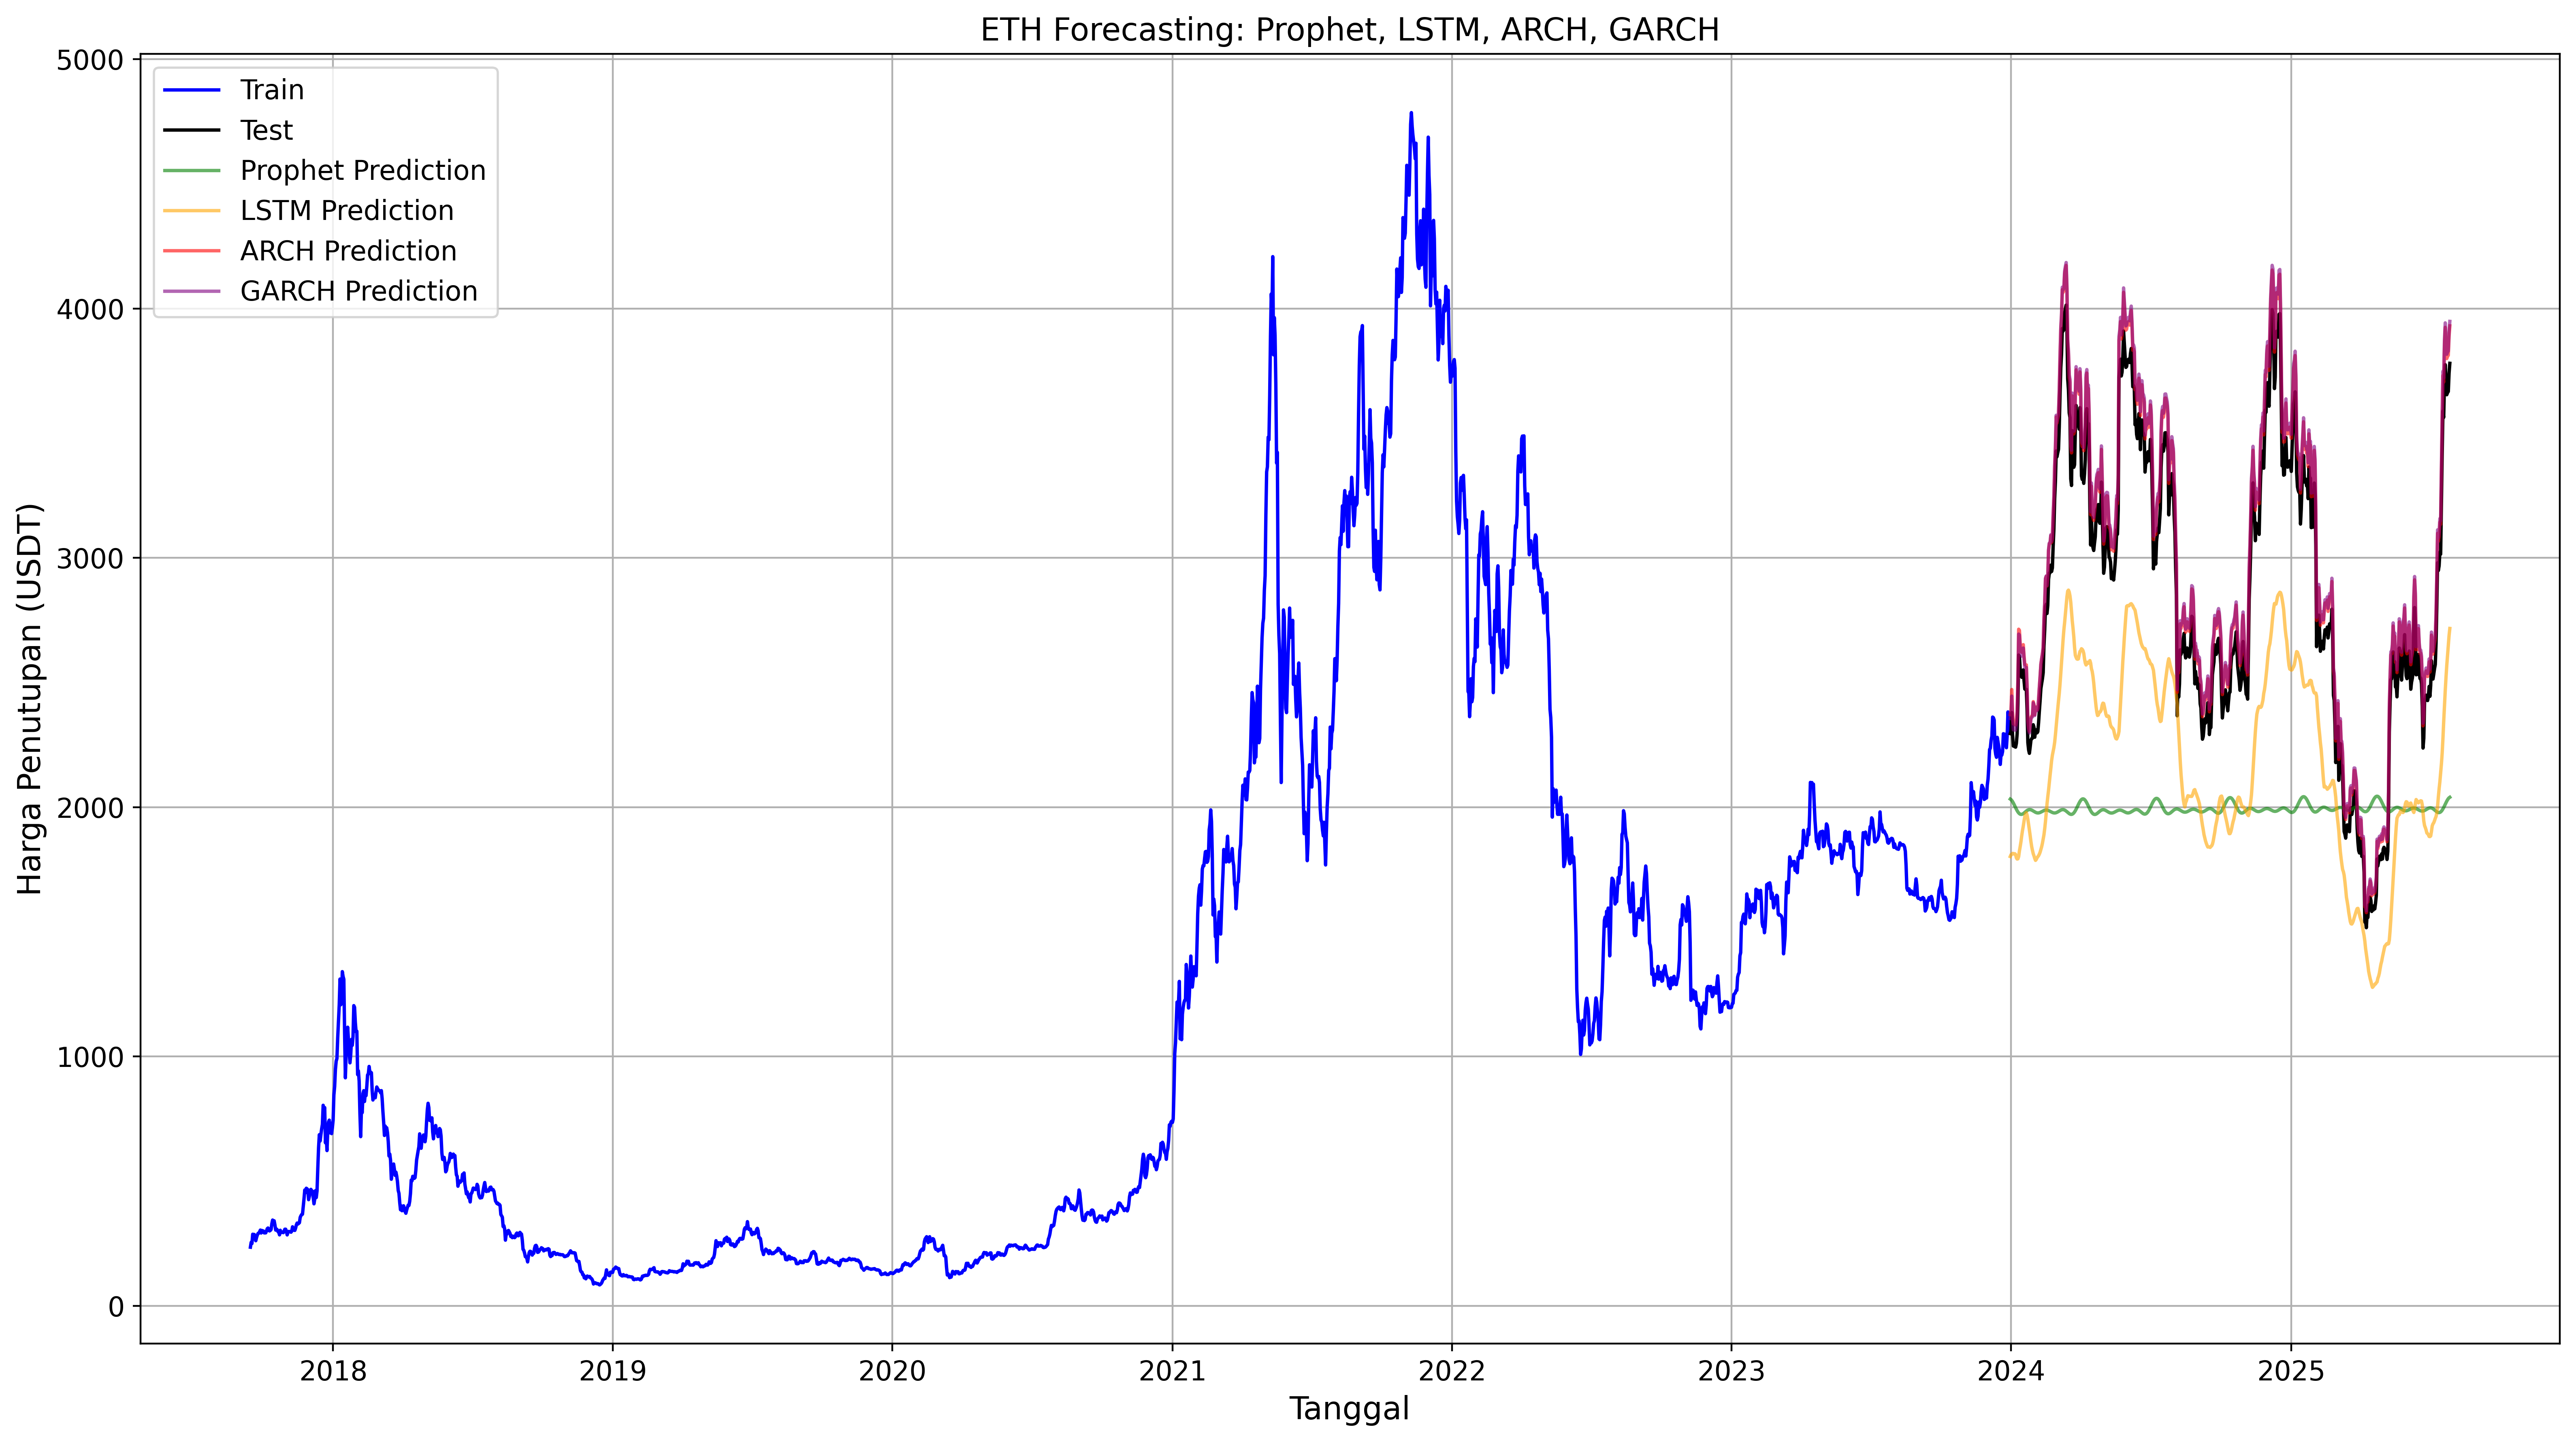

In [126]:
# Hitung return persentase
returns_pct = 100 * df['close'].pct_change().dropna()

# Split train-test
split_idx = int(len(returns_pct) * 0.8)
train_returns = returns_pct.iloc[:split_idx]
test_returns = returns_pct.iloc[split_idx:]

# =============== Visualisasi ===============
plt.figure(figsize=(16,9), dpi=400)
plt.plot(train.index, train.values, label='Train', color='blue')
plt.plot(test.index, test.values, label='Test', color='black')
plt.plot(test.index, prophet_pred, label='Prophet Prediction', color='green', alpha=0.6)
plt.plot(test.index[:len(lstm_pred)], lstm_pred, label='LSTM Prediction', color='orange', alpha=0.6)
plt.plot(test.index[:len(arch_pred)], arch_pred, label='ARCH Prediction', color='red', alpha=0.6)
plt.plot(test.index[:len(garch_pred)], garch_pred, label='GARCH Prediction', color='purple', alpha=0.6)

plt.title('ETH Forecasting: Prophet, LSTM, ARCH, GARCH', fontsize=14)
plt.xlabel('Tanggal', fontsize=14)
plt.ylabel('Harga Penutupan (USDT)', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()


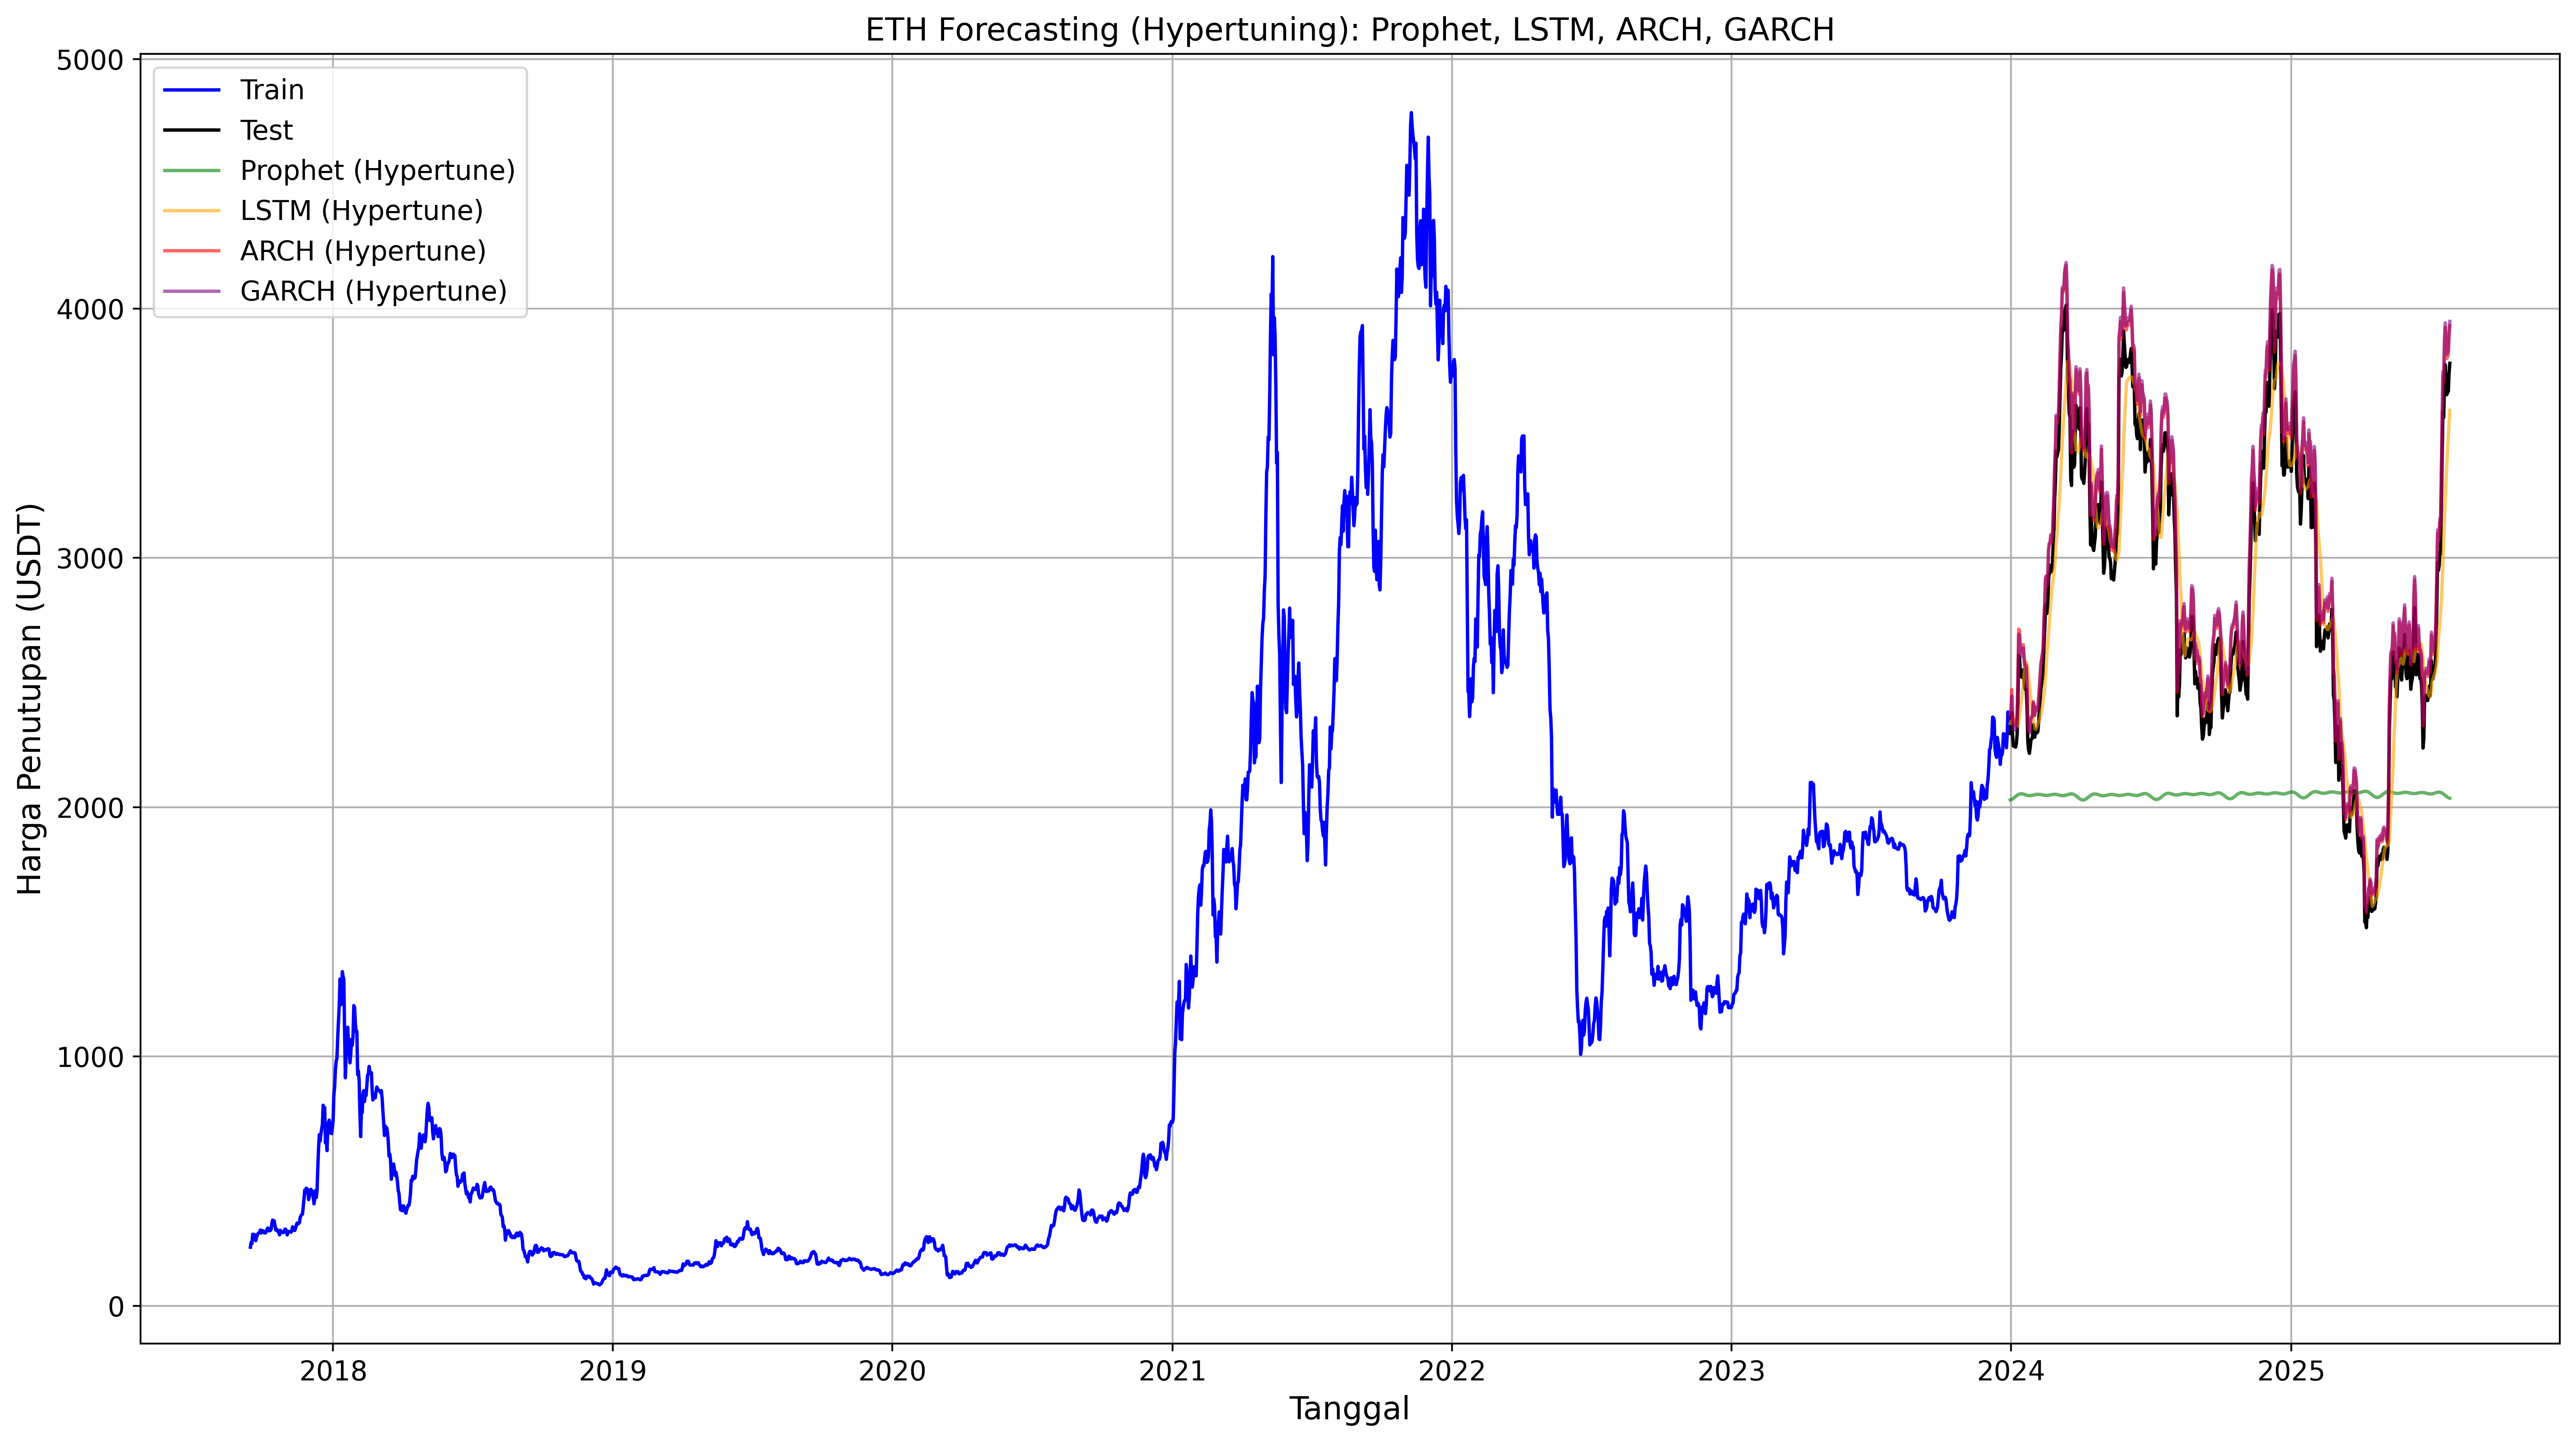

In [127]:
# =============== Visualisasi Model Hypertuning ===============

plt.figure(figsize=(16,9), dpi=400)
plt.plot(train.index, train.values, label='Train', color='blue')
plt.plot(test.index, test.values, label='Test', color='black')

# Plot hasil prediksi hypertuning
plt.plot(test.index, prophet_pred_ht, label='Prophet (Hypertune)', color='green', alpha=0.6)
plt.plot(test.index[:len(lstm_pred_ht)], lstm_pred_ht, label='LSTM (Hypertune)', color='orange', alpha=0.6)
plt.plot(test.index[:len(arch_pred_ht)], arch_pred_ht, label='ARCH (Hypertune)', color='red', alpha=0.6)
plt.plot(test.index[:len(garch_pred_ht)], garch_pred_ht, label='GARCH (Hypertune)', color='purple', alpha=0.6)

plt.title('ETH Forecasting (Hypertuning): Prophet, LSTM, ARCH, GARCH', fontsize=14)
plt.xlabel('Tanggal', fontsize=14)
plt.ylabel('Harga Penutupan (USDT)', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()


## G. Deployment

Deployment App Streamlit

https://etc-price-prediction.streamlit.app/